# Seq++ with PTO: Evolutionary Irish Music Generation

1. **Setup** — Install PTO library, load calibration  
2. **Corpus Analysis** — Explore the Irish tune corpus calibration data  
3. **Generator** — The Seq++ music generator (adapted for PTO's `rnd`)  
4. **Fitness** — Complexity (NPC) + Rhythm scoring  
5. **Evolution** — Run PTO GA to evolve tunes  
6. **Analysis** — Inspect and export results

## 1. Setup

In [2]:
%pip install git+https://github.com/Program-Trace-Optimisation/PTO.git -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pickle, math, os, re
from collections import Counter
from typing import Dict, List, Tuple, Optional, Any
import matplotlib.pyplot as plt
import numpy as np

from pto import run, rnd
print("PTO imported successfully")

# Output directory for plots
os.makedirs('plots', exist_ok=True)

# Supporting modules (keep as .py files alongside this notebook)
import decoder
from decoder import decode_to_melody, decode
from calculate_irish_npc_complete import encode_chunks_incremental, NPCCalculator, VAR_FUNCS

PTO imported successfully


In [4]:
import pickle

with open('cre_calibration.pkl', 'rb') as f:
    calibration = pickle.load(f)

# Fix: sync total_corpus with actual npc_values count
calibration['total_corpus'] = len(calibration['npc_values'])

with open('cre_calibration.pkl', 'wb') as f:
    pickle.dump(calibration, f)

print(f"Fixed: total_corpus now = {calibration['total_corpus']}")

# with open('cre_calibration.pkl', 'rb') as f:
#     calibration = pickle.load(f)

print(f"Corpus size:  {calibration['total_corpus']} tunes")
print(f"NPC mean:     {calibration['npc_mean']:.2f}")
print(f"NPC std:      {calibration['npc_std']:.2f}")
print(f"NPC values:   {len(calibration.get('npc_values', []))} computed")
print(f"Time sigs:    {list(calibration['pattern_tables'].keys())}")
for ts, table in calibration['pattern_tables'].items():
    total = sum(table.values())
    print(f"  {ts}: {len(table)} unique patterns from {total} tunes")

Fixed: total_corpus now = 1195
Corpus size:  1195 tunes
NPC mean:     138.56
NPC std:      49.20
NPC values:   1195 computed
Time sigs:    ['4/4', '6/8', '9/8', '12/8', '2/4']
  4/4: 742 unique patterns from 743 tunes
  6/8: 248 unique patterns from 260 tunes
  9/8: 52 unique patterns from 52 tunes
  12/8: 76 unique patterns from 76 tunes
  2/4: 83 unique patterns from 83 tunes


## 2. Corpus Analysis

### 2.1 NPC Distribution

NPC (Nested Pattern Complexity) measures the cost of constructing a tune's hierarchical representation. 
The fitness function rewards generated tunes whose NPC is close to the corpus mean.

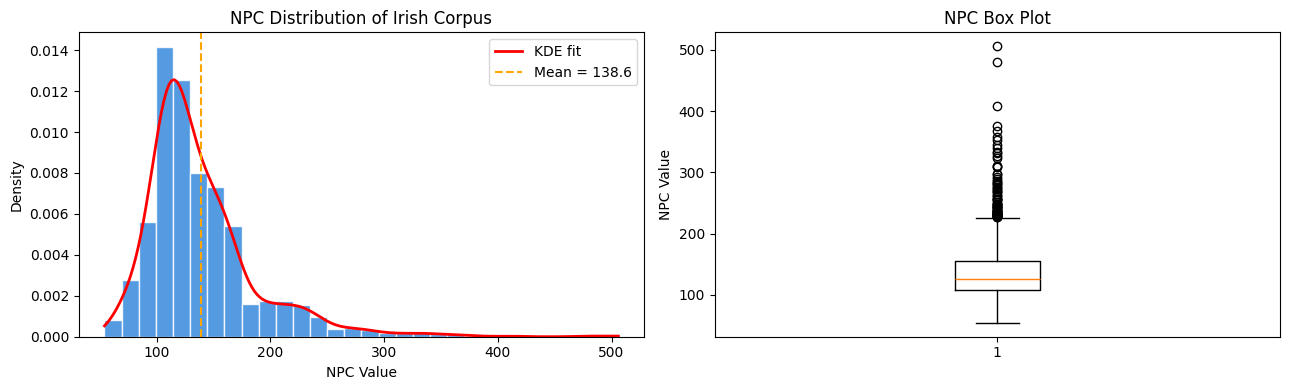

Min: 54.0, Q1: 108.0, Median: 126.0, Q3: 155.0, Max: 506.0


In [5]:
npc_values = calibration.get('npc_values', [])

if npc_values:
    from scipy.stats import gaussian_kde
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(npc_values, bins=30, color='#378ADD', edgecolor='white', alpha=0.85, density=True)
    # Overlay KDE
    x_grid = np.linspace(min(npc_values), max(npc_values), 200)
    kde = gaussian_kde(npc_values)
    axes[0].plot(x_grid, kde(x_grid), 'r-', linewidth=2, label='KDE fit')
    axes[0].axvline(calibration['npc_mean'], color='orange', linestyle='--', linewidth=1.5, label=f"Mean = {calibration['npc_mean']:.1f}")
    axes[0].set_xlabel('NPC Value'); axes[0].set_ylabel('Density')
    axes[0].set_title('NPC Distribution of Irish Corpus'); axes[0].legend()
    axes[1].boxplot(npc_values, vert=True)
    axes[1].set_ylabel('NPC Value'); axes[1].set_title('NPC Box Plot')
    plt.tight_layout()
    plt.savefig('plots/npc_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Min: {min(npc_values):.1f}, Q1: {np.percentile(npc_values,25):.1f}, "
          f"Median: {np.median(npc_values):.1f}, Q3: {np.percentile(npc_values,75):.1f}, Max: {max(npc_values):.1f}")
else:
    print("No NPC values in calibration (rhythm-only calibration)")

### 2.2 Rhythm Profiles

Each tune's note onsets are collapsed into a single-bar histogram at 16th-note resolution.
The corpus provides a table of all unique histograms per time signature, each with a frequency count.

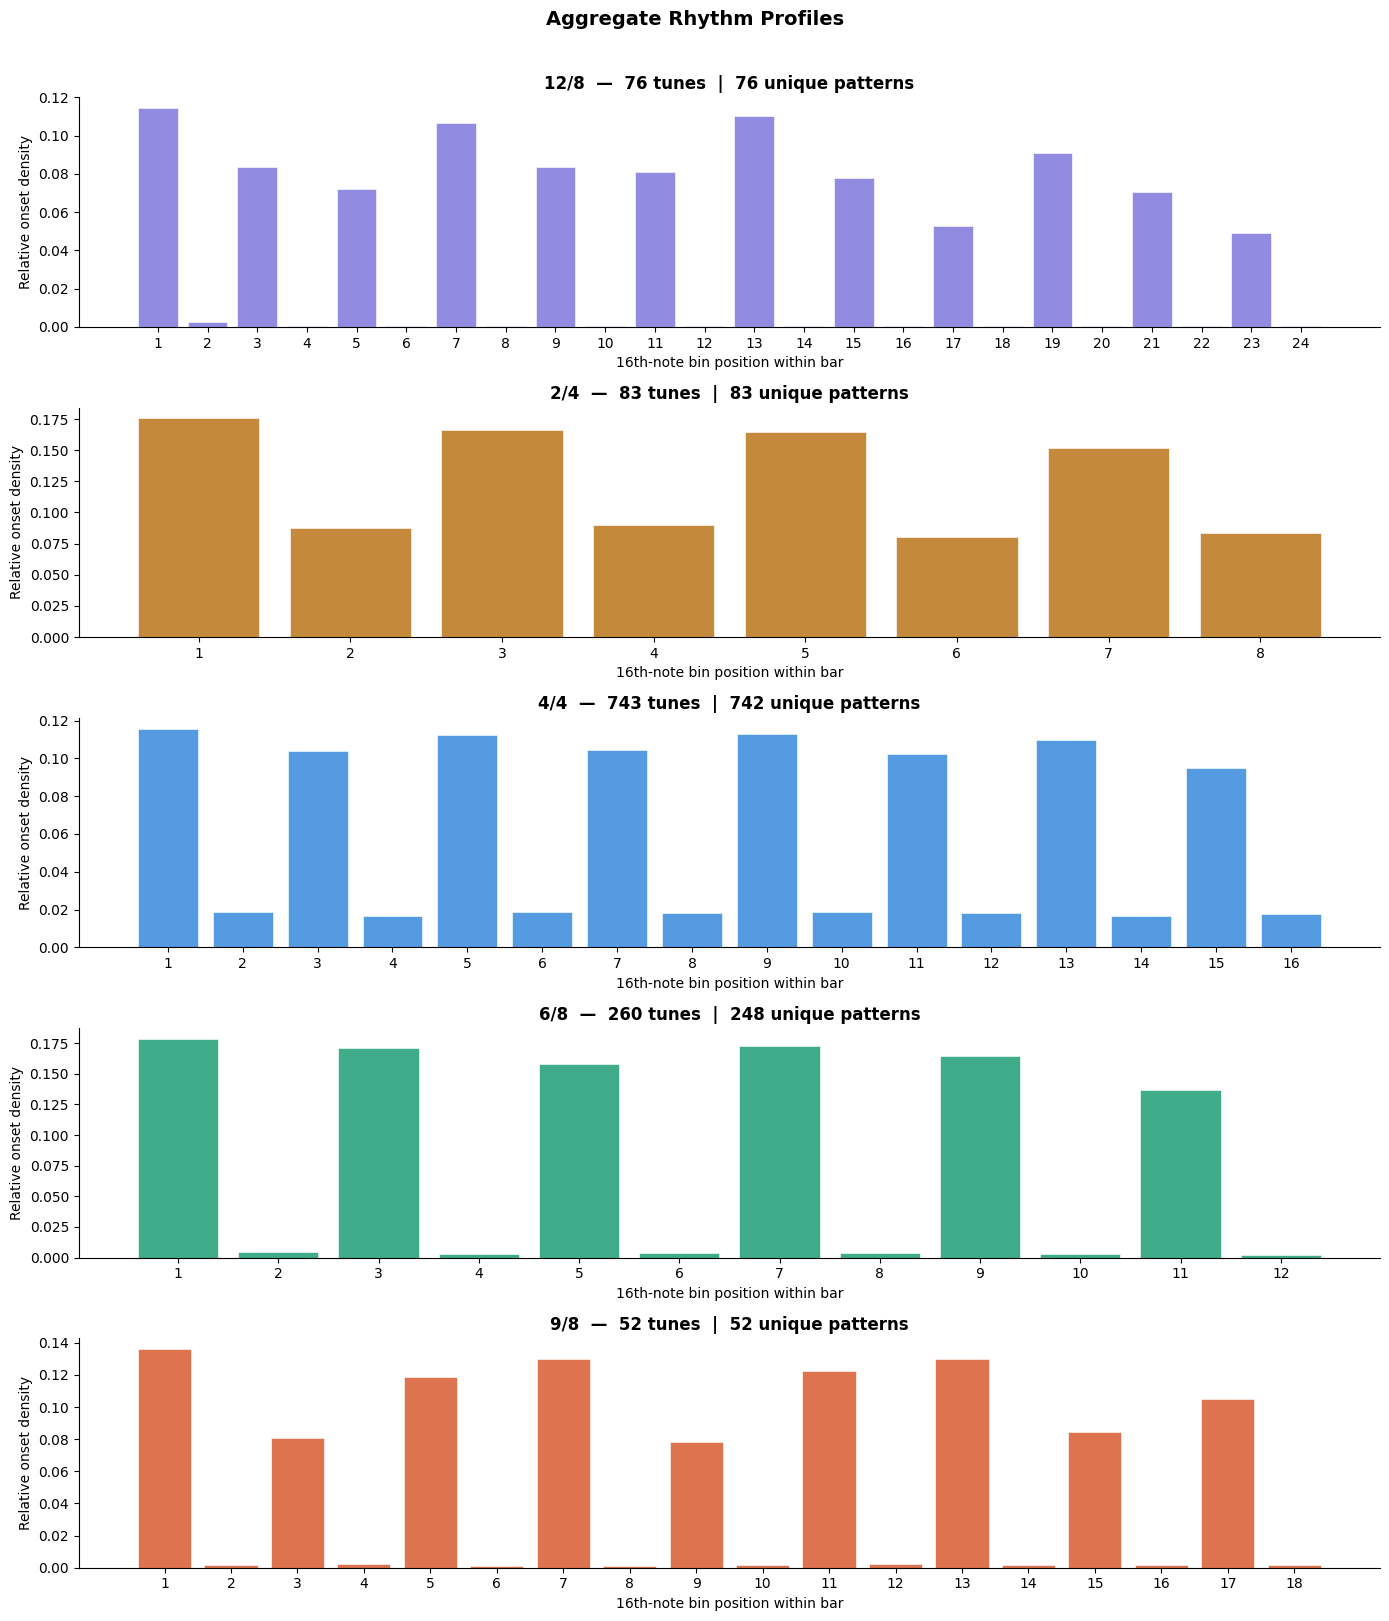

In [5]:
TS_COLORS = {'6/8': '#1D9E75', '4/4': '#378ADD', '9/8': '#D85A30',
             '12/8': '#7F77DD', '2/4': '#BA7517', '3/4': '#D4537E'}
tables = calibration['pattern_tables']
ts_list = sorted(tables.keys())
n = len(ts_list)
fig, axes = plt.subplots(n, 1, figsize=(14, 3.2 * n))
if n == 1: axes = [axes]
for idx, ts in enumerate(ts_list):
    table = tables[ts]
    n_bins = len(next(iter(table)))
    agg = [0.0] * n_bins
    total = sum(table.values())
    for hist, count in table.items():
        for i, v in enumerate(hist):
            agg[i] += v * count
    s = sum(agg)
    if s > 0: agg = [v / s for v in agg]
    ax = axes[idx]
    ax.bar(range(1, n_bins + 1), agg, color=TS_COLORS.get(ts, '#888'), alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(f"{ts}  \u2014  {total} tunes  |  {len(table)} unique patterns", fontsize=12, fontweight='bold')
    ax.set_xlabel("16th-note bin position within bar"); ax.set_ylabel("Relative onset density")
    ax.set_xticks(range(1, n_bins + 1)); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle("Aggregate Rhythm Profiles", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/rhythm_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Pattern Frequency Analysis

In [7]:
for ts in sorted(tables.keys()):
    table = tables[ts]
    total = sum(table.values())
    sorted_patterns = sorted(table.values(), reverse=True)
    print(f"\n{'='*50}")
    print(f"{ts}: {len(table)} patterns from {total} tunes")
    print(f"{'='*50}")
    cumulative = 0
    for i, count in enumerate(sorted_patterns, 1):
        cumulative += count
        pct = cumulative / total * 100
        if pct >= 50 and i == next(j for j, c in enumerate(sorted_patterns, 1) if sum(sorted_patterns[:j]) / total * 100 >= 50):
            print(f"  Top {i} patterns cover 50% of tunes")
        if pct >= 80 and i == next(j for j, c in enumerate(sorted_patterns, 1) if sum(sorted_patterns[:j]) / total * 100 >= 80):
            print(f"  Top {i} patterns cover 80% of tunes")
        if pct >= 90 and i == next(j for j, c in enumerate(sorted_patterns, 1) if sum(sorted_patterns[:j]) / total * 100 >= 90):
            print(f"  Top {i} patterns cover 90% of tunes")
            break
    sorted_p = sorted(table.items(), key=lambda x: -x[1])[:5]
    print(f"  Top 5 patterns:")
    for rank, (pattern, count) in enumerate(sorted_p, 1):
        pct = count / total * 100
        active = [(i, round(v, 2)) for i, v in enumerate(pattern) if v > 0.005]
        print(f"    #{rank}: {count} tunes ({pct:.1f}%) \u2014 active bins: {active}")


12/8: 76 patterns from 76 tunes
  Top 38 patterns cover 50% of tunes
  Top 61 patterns cover 80% of tunes
  Top 69 patterns cover 90% of tunes
  Top 5 patterns:
    #1: 1 tunes (1.3%) — active bins: [(0, 0.13), (1, 0.01), (2, 0.13), (6, 0.1), (8, 0.13), (12, 0.1), (14, 0.13), (16, 0.03), (18, 0.1), (20, 0.13), (22, 0.02)]
    #2: 1 tunes (1.3%) — active bins: [(0, 0.12), (2, 0.03), (4, 0.1), (6, 0.12), (8, 0.03), (10, 0.12), (12, 0.12), (14, 0.04), (16, 0.12), (18, 0.12), (22, 0.07)]
    #3: 1 tunes (1.3%) — active bins: [(0, 0.1), (2, 0.12), (6, 0.12), (8, 0.12), (10, 0.09), (12, 0.12), (14, 0.12), (16, 0.03), (18, 0.06), (20, 0.12), (22, 0.01)]
    #4: 1 tunes (1.3%) — active bins: [(0, 0.11), (2, 0.08), (4, 0.11), (6, 0.1), (8, 0.04), (10, 0.1), (12, 0.1), (14, 0.1), (16, 0.1), (18, 0.1), (22, 0.08)]
    #5: 1 tunes (1.3%) — active bins: [(0, 0.11), (2, 0.13), (4, 0.05), (6, 0.13), (8, 0.13), (12, 0.13), (14, 0.13), (18, 0.06), (20, 0.13)]

2/4: 83 patterns from 83 tunes
  Top 42 p

## 3. Generator (Seq++ for PTO)

The generator creates a hierarchical music structure using `rnd` (PTO's traced random module).
Every `rnd.*` call is recorded by PTO as part of the program trace (genotype). 
The music structure returned is the phenotype.

In [6]:
# =============================================================================
# Seq++ Generator — uses PTO's `rnd`
# =============================================================================

def generate(
    chunks_range=(4, 6), chunk_length_range=(1, 4),
    ho_patterns_range=(0, 1), au_patterns_range=(0, 3),
    grammar_range=(2, 3), element_length_range=(3, 5),
    transform_prob=0.40, ho_transform_prob=0.25,
    transposition_intervals=None, pitch_range=(0, 7),
):
    """Seq++ music generator. All random decisions use PTO's `rnd`."""

    def create_random_duration_partition(target_duration, feel):
        """Create a random partition of a target musical duration."""
        durations = []
        remaining = target_duration
        if feel == 'straight':
            all_types = [(2, 10), (1, 30), (0.5, 40), (0.25, 20)]
        else:
            all_types = [(1, 30), (2/3, 20), (1/3, 60), (1/6, 20)]
        # num_types = rnd.choice([2, 3])
        # note_types = rnd.sample(all_types, min(num_types, len(all_types)))

        use_mask = [rnd.random() < 0.7 for _ in all_types]
        note_types = [t for t, use in zip(all_types, use_mask) if use]
        if not note_types:
            note_types = [all_types[rnd.randint(0, len(all_types) - 1)]]
            
        max_notes = int(target_duration / min(d for d, _ in note_types)) + 2
        for _ in range(max_notes):
            if remaining <= 0.01:
                break
            choices, weights = [], []
            for note_len, weight in note_types:
                if note_len <= remaining + 0.01:
                    choices.append(note_len)
                    weights.append(weight)
            if not choices:
                break
            chosen = rnd.choices(choices, weights=weights)[0]
            durations.append(chosen)
            remaining -= chosen
        return durations
    if transposition_intervals is None:
        transposition_intervals = [-5, -3, -2, 2, 3, 5]

    num_chunks = rnd.randint(*chunks_range)
    num_ho_patterns = rnd.randint(*ho_patterns_range)
    num_au_patterns = rnd.randint(*au_patterns_range)
    time_sig = rnd.choice(['4/4', '3/4', '2/4', '6/8', '9/8', '12/8'])
    feel = 'triplet' if rnd.random() < 0.15 else 'straight'
    # feel = rnd.choices(['straight', 'triplet'], weights=[85, 15])[0]
    
    # 1. Chunks
    chunks = {}
    for i in range(num_chunks):
        chunk_length = rnd.randint(*chunk_length_range)
        note_durations = create_random_duration_partition(chunk_length, feel)
        notes = [(rnd.randint(*pitch_range), d) for d in note_durations]
        chunks[f"c_{i}"] = notes

    # 2. HO patterns
    ho_patterns = {}
    for i in range(num_ho_patterns):
        ho_len = rnd.randint(*element_length_range)
        ho_patterns[f"ho_{i}"] = [f"c_{rnd.randint(0, num_chunks - 1)}" for _ in range(ho_len)]

    # 3. AU patterns
    au_patterns = {}
    for i in range(num_au_patterns):
        num_variables = rnd.choice([1, 2])
        pattern_length = rnd.randint(*element_length_range)
        if num_variables == 1:
            variables = ["X1"]
            pattern_type = rnd.choice(["transpose_var", "mixed"])
            if pattern_type == "transpose_var":
                c1, c2 = rnd.randint(0, num_chunks-1), rnd.randint(0, num_chunks-1)
                pattern = [f"c_{c1}", f"T(c_{c2},X1)"]
            else:
                pattern = []
                for _ in range(pattern_length):
                    ci = rnd.randint(0, num_chunks - 1)
                    tt = rnd.choice(["plain", "transpose", "invert", "augment"])
                    if tt == "plain":      pattern.append(f"c_{ci}")
                    elif tt == "transpose": pattern.append(f"T(c_{ci},X1)")
                    elif tt == "invert":    pattern.append(f"I(c_{ci},X1)")
                    elif tt == "augment":   pattern.append(f"A(c_{ci},X1)")
        else:
            variables = ["X1", "X2"]
            ci = rnd.randint(0, num_chunks - 1)
            # pattern = rnd.choice([
            #     [f"c_{ci}", "X1", f"T(c_{ci},X2)", "T(X1,X2)"],
            #     [f"c_{ci}", "T(X1,X2)", f"G(c_{ci})"],
            #     ["X1", f"T(c_{ci},X2)", "X1"],
            #     ["X1", f"G(c_{ci})", "T(X1,X2)"],
            #     [f"c_{ci}", "X1", "T(X1,X2)"],
            # ])
            _templates = [
                [f"c_{ci}", "X1", f"T(c_{ci},X2)", "T(X1,X2)"],
                [f"c_{ci}", "T(X1,X2)", f"G(c_{ci})"],
                ["X1", f"T(c_{ci},X2)", "X1"],
                ["X1", f"G(c_{ci})", "T(X1,X2)"],
                [f"c_{ci}", "X1", "T(X1,X2)"],
            ]
            pattern = _templates[rnd.randint(0, 4)]
        au_patterns[f"f_{i}"] = {"pattern": pattern, "variables": variables}

    # 4. Grammar
    grammar = {}
    # forms = [["p_1","p_2","p_1"], ["p_1","p_2","p_1","p_2"], ["p_1","p_2","p_2","p_1"]]
    # grammar["p_0"] = rnd.choice(forms)

    form_idx = rnd.randint(0, 2)
    forms = [["p_1","p_2","p_1"], ["p_1","p_2","p_1","p_2"], ["p_1","p_2","p_2","p_1"]]
    grammar["p_0"] = forms[form_idx]

    rules_to_generate = set(grammar["p_0"])
    rules_generated = {"p_0"}
    next_rule_num = max(int(r.split("_")[1]) for r in grammar["p_0"]) + 1

    while rules_to_generate:
        rule_name = min(rules_to_generate)
        rules_to_generate.remove(rule_name)
        rules_generated.add(rule_name)
        rule_length = rnd.randint(*element_length_range)
        elements = []
        for _ in range(rule_length):
            available_types = ["chunk"]
            if num_ho_patterns > 0: available_types.append("ho_pattern")
            if num_au_patterns > 0: available_types.append("au_pattern")
            if rnd.random() < 0.4:  available_types.append("grammar_rule")
            element_type = rnd.choice(available_types)

            if element_type == "chunk":
                chunk_ref = f"c_{rnd.randint(0, num_chunks - 1)}"
                if rnd.random() < transform_prob:
                    trans = rnd.choices(["T", "G", "I", "P", "H"], weights=[80, 5, 5, 5, 5])[0]
                    if trans == "T":
                        elements.append(f"T({chunk_ref},{rnd.choice(transposition_intervals)})")
                    elif trans == "G":
                        elements.append(f"G({chunk_ref})")
                    elif trans == "I":
                        elements.append(f"I({chunk_ref},0)")
                    elif trans == "P":
                        pos = rnd.randint(0, len(chunks[chunk_ref]) - 1)
                        elements.append(f"P({chunk_ref},{pos},{rnd.randint(0, 7)})")
                    elif trans == "H":
                        pos = rnd.randint(0, len(chunks[chunk_ref]) - 1)
                        elements.append(f"H({chunk_ref},{pos},{rnd.choice([0.5, 1, 1.5])})")
                else:
                    elements.append(chunk_ref)
            elif element_type == "ho_pattern" and num_ho_patterns > 0:
                ho_ref = f"ho_{rnd.randint(0, num_ho_patterns - 1)}"
                if rnd.random() < ho_transform_prob:
                    trans = rnd.choices(["T", "G", "A", "D"], weights=[80, 7, 7, 6])[0]
                    if trans == "T":   elements.append(f"T({ho_ref},{rnd.choice(transposition_intervals)})")
                    elif trans == "G": elements.append(f"G({ho_ref})")
                    elif trans == "A": elements.append(f"A({ho_ref},{rnd.choice([2, 3])})")
                    elif trans == "D": elements.append(f"D({ho_ref},2)")
                else:
                    elements.append(ho_ref)
            elif element_type == "au_pattern" and num_au_patterns > 0:
                func_idx = rnd.randint(0, num_au_patterns - 1)
                num_vars = len(au_patterns[f"f_{func_idx}"]["variables"])
                if num_vars == 1:
                    elements.append(f"f_{func_idx}({rnd.choice(transposition_intervals)})")
                else:
                    elements.append(f"f_{func_idx}(c_{rnd.randint(0, num_chunks-1)},{rnd.choice(transposition_intervals)})")
            elif element_type == "grammar_rule":
                existing = [e for e in elements if e.startswith("p_")]
                if existing and rnd.random() < 0.7:
                    elements.append(rnd.choice(existing))
                else:
                    new_rule = f"p_{next_rule_num}"
                    next_rule_num += 1
                    elements.append(new_rule)
                    rules_to_generate.add(new_rule)
                    if rnd.random() < 0.5:
                        elements.append(new_rule)
        grammar[rule_name] = elements

    return {"chunks": chunks, "ho_patterns": ho_patterns,
            "au_patterns": au_patterns, "grammar": grammar, "time_sig": time_sig}


def expand_music_data(music_data):
    """Expand a music data dict to a flat melody."""
    chunks = music_data['chunks']
    ho_p = {k: {"base_segment": v} for k, v in music_data.get('ho_patterns', {}).items()}
    return decode_to_melody(music_data['grammar'], chunks,
                            ho_patterns=ho_p, au_patterns=music_data.get('au_patterns', {}), start="p_0")

print("Generator defined.")

Generator defined.


In [7]:
# Quick test
test_data = generate()
test_melody = expand_music_data(test_data)
print(f"Generated tune: {len(test_melody)} notes, time_sig={test_data['time_sig']}")
print(f"  Chunks: {len(test_data['chunks'])}, HO: {len(test_data['ho_patterns'])}")
print(f"  Grammar rules: {list(test_data['grammar'].keys())}")
print(f"  p_0 = {test_data['grammar']['p_0']}")
print(f"  First 10 notes: {test_melody[:10]}")

# Save test tune as MIDI
scale = [0, 2, 3, 5, 7, 9, 11]
midi_melody = []
for p, d in test_melody:
    midi_pitch = 60 + (p // 7) * 12 + scale[p % 7]
    midi_melody.append((midi_pitch, int(round(d * 480))))
decoder.save_melody_to_midi(midi_melody, 'test_tune.mid', ticks_per_beat=480, tempo_bpm=120)
print(f"  Saved test_tune.mid")

Generated tune: 656 notes, time_sig=12/8
  Chunks: 5, HO: 0
  Grammar rules: ['p_0', 'p_1', 'p_2', 'p_3', 'p_4']
  p_0 = ['p_1', 'p_2', 'p_2', 'p_1']
  First 10 notes: [(4, 0.5), (7, 0.25), (3, 0.5), (3, 0.5), (1, 1), (5, 0.5), (0, 0.5), (3, 0.25), (7, 0.5), (7, 0.25)]
Saved MIDI file: test_tune.mid
  Saved test_tune.mid


In [8]:
# Detailed inspection of a generated tune
import numpy as np
from collections import Counter

d = generate()
melody = expand_music_data(d)

print("=" * 60)
print("OVERVIEW")
print("=" * 60)
print(f"  Time signature : {d['time_sig']}")
print(f"  Total notes    : {len(melody)}")
print(f"  Chunks         : {len(d['chunks'])}")
print(f"  HO patterns    : {len(d['ho_patterns'])}")
print(f"  AU patterns    : {len(d['au_patterns'])}")
print(f"  Grammar rules  : {len(d['grammar'])}")

# ── GRAMMAR ──────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("GRAMMAR RULES")
print("=" * 60)
for rule, rhs in d['grammar'].items():
    print(f"  {rule:>6} ->  {' '.join(str(s) for s in rhs)}")

# ── CHUNKS ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("CHUNKS")
print("=" * 60)
for name, notes in d['chunks'].items():
    pitches = [p for p, _ in notes]
    durs    = [dur for _, dur in notes]
    print(f"  {name}  ({len(notes)} notes, {sum(durs):.2f} beats)")
    print(f"    pitches : {pitches}  [min={min(pitches)}, max={max(pitches)}]")
    print(f"    durs    : {[round(x,3) for x in durs]}")
    print(f"    notes   : {notes}")

# ── HO PATTERNS ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("HO PATTERNS  (Higher-Order)")
print("=" * 60)
if d['ho_patterns']:
    for name, refs in d['ho_patterns'].items():
        print(f"  {name} -> {refs}")
        total_notes = sum(len(d['chunks'].get(r, [])) for r in refs)
        print(f"    expands to ~{total_notes} notes across {len(refs)} chunk refs")
else:
    print("  (none)")

# ── AU / VARIATIONAL PATTERNS ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("AU PATTERNS  (Variational / Abstract)")
print("=" * 60)
if d['au_patterns']:
    for name, spec in d['au_patterns'].items():
        print(f"  {name}")
        print(f"    variables : {spec['variables']}  (arity={len(spec['variables'])})")
        print(f"    pattern   : {spec['pattern']}")
        ops = Counter()
        for token in spec['pattern']:
            if isinstance(token, str) and '(' in token:
                ops[token.split('(')[0]] += 1
            else:
                ops['plain_ref'] += 1
        print(f"    op counts : {dict(ops)}")
else:
    print("  (none)")

# ── FULL NOTE SEQUENCE ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FULL NOTE SEQUENCE  (pitch, duration)")
print("=" * 60)
for i, (p, dur) in enumerate(melody):
    print(f"  [{i:>4}]  pitch={p:>2}  dur={dur:.4f}")

# ── NOTE STATISTICS ───────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("NOTE STATISTICS")
print("=" * 60)
pitches = [p for p, _ in melody]
durs    = [dur for _, dur in melody]
print(f"  Pitch  : min={min(pitches)}  max={max(pitches)}  mean={np.mean(pitches):.2f}  std={np.std(pitches):.2f}")
print(f"  Dur    : min={min(durs):.4f}  max={max(durs):.4f}  mean={np.mean(durs):.4f}  std={np.std(durs):.4f}")
print(f"  Total beats : {sum(durs):.2f}")
print(f"  Pitch dist  : { {k: Counter(pitches)[k] for k in sorted(Counter(pitches))} }")
print(f"  Dur dist    : { {k: Counter(durs)[k] for k in sorted(Counter(durs))} }")


OVERVIEW
  Time signature : 6/8
  Total notes    : 486
  Chunks         : 4
  HO patterns    : 0
  AU patterns    : 2
  Grammar rules  : 5

GRAMMAR RULES
     p_0 ->  p_1 p_2 p_1 p_2
     p_1 ->  f_0(3) c_3 f_0(2) f_0(-5)
     p_2 ->  f_1(-3) H(c_2,3,1.5) p_3 c_2 c_2
     p_3 ->  p_4 f_1(-5) f_1(5) c_1 f_0(5)
     p_4 ->  f_0(2) f_0(2) T(c_1,-2)

CHUNKS
  c_0  (6 notes, 3.00 beats)
    pitches : [2, 0, 7, 2, 1, 6]  [min=0, max=7]
    durs    : [0.667, 0.333, 0.667, 0.333, 0.667, 0.333]
    notes   : [(2, 0.6666666666666666), (0, 0.3333333333333333), (7, 0.6666666666666666), (2, 0.3333333333333333), (1, 0.6666666666666666), (6, 0.3333333333333333)]
  c_1  (7 notes, 4.00 beats)
    pitches : [2, 2, 4, 3, 5, 3, 3]  [min=2, max=5]
    durs    : [0.667, 0.667, 0.667, 1, 0.667, 0.167, 0.167]
    notes   : [(2, 0.6666666666666666), (2, 0.6666666666666666), (4, 0.6666666666666666), (3, 1), (5, 0.6666666666666666), (3, 0.16666666666666666), (3, 0.16666666666666666)]
  c_2  (5 notes, 3.00 beats)

In [11]:
# # Generate 20 raw tunes and save as MIDI
# os.makedirs('raw_tunes', exist_ok=True)
# scale = [0, 2, 3, 5, 7, 9, 11]

# for i in range(20):
#     data = generate()
#     melody = expand_music_data(data)
#     print(f"raw_{i:02d}: {len(melody)} notes, time_sig={data['time_sig']}")
#     print(f"  Chunks: {len(data['chunks'])}, HO: {len(data['ho_patterns'])}")
#     print(f"  Grammar rules: {list(data['grammar'].keys())}")
#     print(f"  p_0 = {data['grammar']['p_0']}")
    
#     midi_melody = []
#     for p, d in melody:
#         midi_pitch = 60 + (p // 7) * 12 + scale[p % 7]
#         midi_melody.append((midi_pitch, int(round(d * 480))))
#     decoder.save_melody_to_midi(midi_melody, f'raw_tunes/raw_{i:02d}.mid', ticks_per_beat=480, tempo_bpm=120)

# print(f"\nSaved 20 tunes to raw_tunes/")

## 4. Fitness Function

Two components calibrated from the corpus:
- **Complexity**: Length-adjusted KDE. A linear model predicts expected NPC from encoding length, then KDE scores the residual (actual - predicted). Rewards tunes with corpus-typical complexity *for their length*.  
- **Rhythm**: Mean cosine similarity to the K=5 nearest corpus rhythm patterns (KNN). This naturally rewards tunes sitting in dense regions of the corpus rhythm space.

MODEL COMPARISON: NPC Length-Adjustment
Model                      R²  Resid std  Resid mean
-------------------------------------------------------
No adjustment          0.0000      49.18      0.0000
Linear                 0.6422      29.42     -0.0000
Quadratic              0.6434      29.37     -0.0000
Log + Linear           0.6452      29.30      0.0000
Sqrt + Linear          0.6447      29.32      0.0000

NPC PER NOTE BY LENGTH BIN (evidence of sub-linear growth)
                n    mean_len    mean_npc  npc_per_note
bin                                                    
(0, 40]     320.0   32.481250  103.006250      3.171253
(40, 60]     94.0   48.851064  121.446809      2.486063
(60, 80]    652.0   64.886503  139.202454      2.145322
(80, 100]    51.0   95.235294  200.901961      2.109533
(100, 140]   45.0  125.733333  247.444444      1.968010
(140, 250]   32.0  168.343750  267.250000      1.587526


/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_49976/3613237840.py:77: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('bin').apply(lambda g: pd.Series({
/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_49976/3613237840.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby('bin').apply(lambda g: pd.Series({


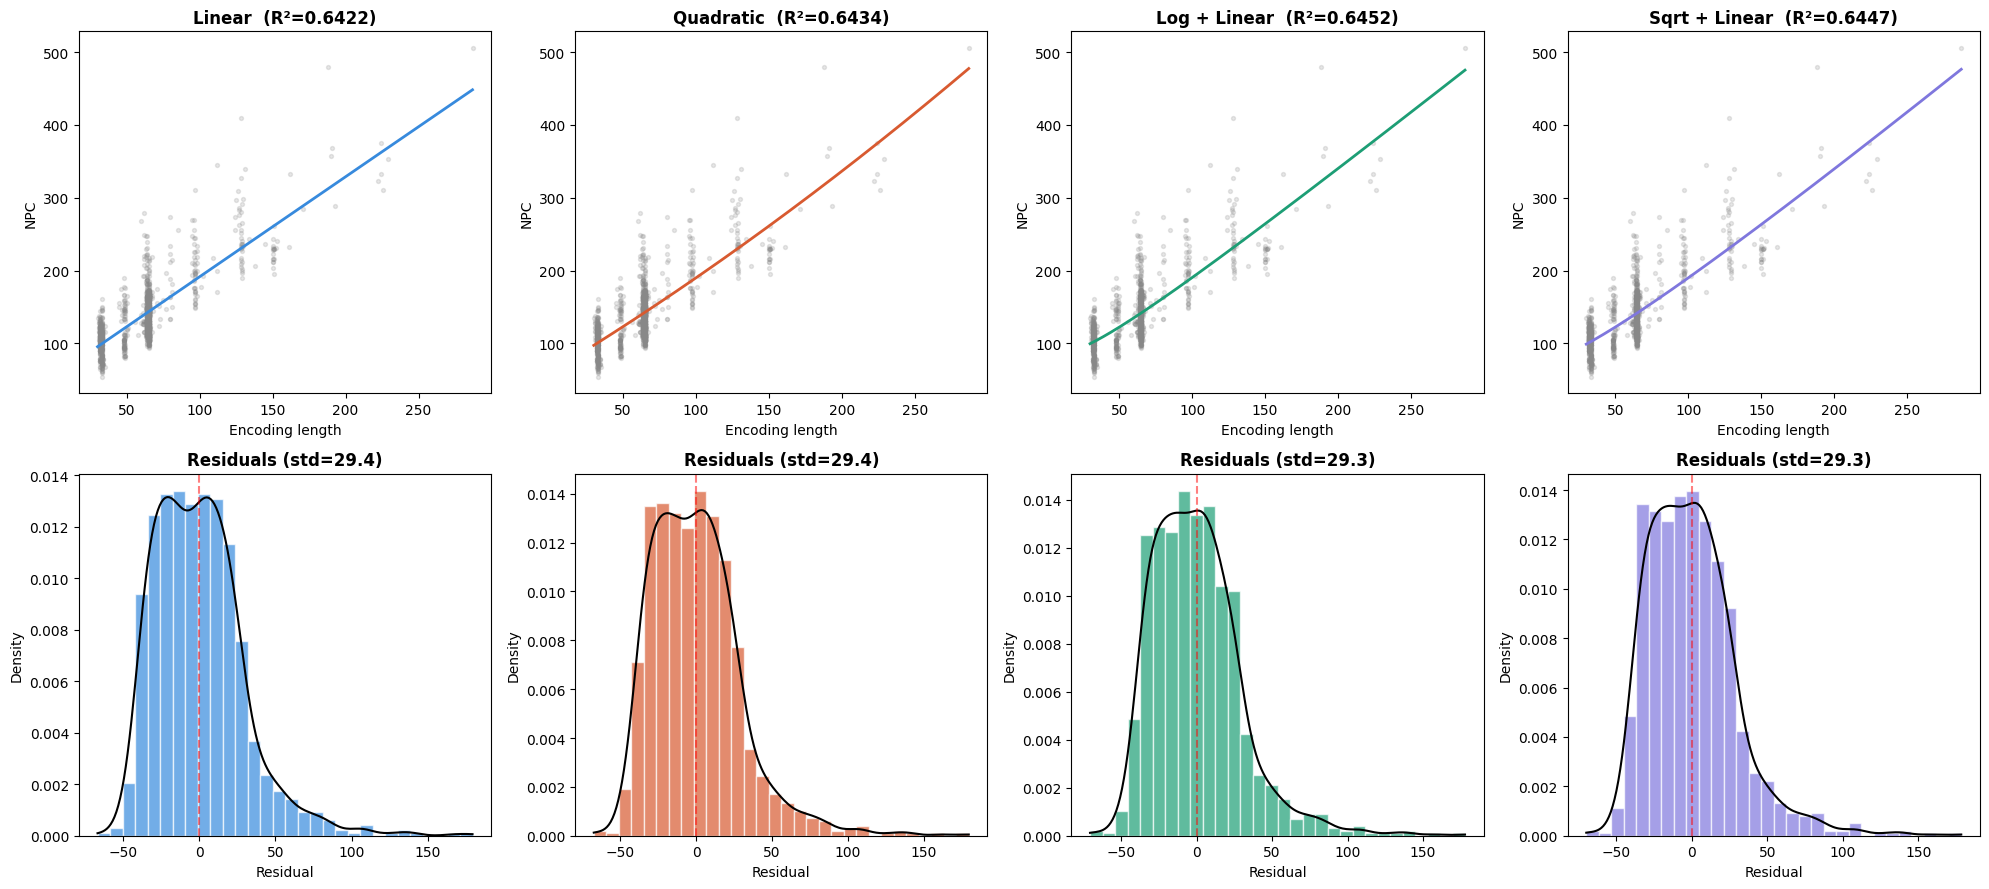


CONCLUSION
Best model by residual std: Log + Linear (std=29.30)
All models with a linear term give nearly identical R² (~0.656-0.660)
The choice of model has minimal impact on downstream KDE scoring.
NPC-per-note does decrease with length (from 3.15 to 1.60),
confirming sub-linear growth, but the effect is too subtle to
meaningfully differentiate regression models at this corpus size.


In [ ]:
# =============================================================================
# NPC Length-Adjustment: Model Comparison
# =============================================================================
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

df = pd.read_csv('irish_npc_results.csv')
L = df['encoding_length'].values
N = df['NPC_total'].values

# --- 1. Fit all models ---
models = {}

# No adjustment (raw NPC)
models['No adjustment'] = {
    'pred': np.full_like(N, N.mean(), dtype=float),
    'label': f'NPC = {N.mean():.1f} (constant)',
}

# Linear
c1 = np.polyfit(L, N, 1)
models['Linear'] = {
    'pred': np.poly1d(c1)(L),
    'label': f'NPC = {c1[0]:.2f}·L + {c1[1]:.1f}',
    'coeffs': c1,
}

# Quadratic
c2 = np.polyfit(L, N, 2)
models['Quadratic'] = {
    'pred': np.poly1d(c2)(L),
    'label': f'NPC = {c2[0]:.4f}·L² + {c2[1]:.2f}·L + {c2[2]:.1f}',
    'coeffs': c2,
}

# Log + Linear
X_log = np.column_stack([np.log(L), L, np.ones_like(L)])
c_log, *_ = np.linalg.lstsq(X_log, N, rcond=None)
models['Log + Linear'] = {
    'pred': X_log @ c_log,
    'label': f'NPC = {c_log[0]:.1f}·log(L) + {c_log[1]:.2f}·L + {c_log[2]:.1f}',
    'coeffs': c_log,
}

# Sqrt + Linear
X_sqrt = np.column_stack([np.sqrt(L), L, np.ones_like(L)])
c_sqrt, *_ = np.linalg.lstsq(X_sqrt, N, rcond=None)
models['Sqrt + Linear'] = {
    'pred': X_sqrt @ c_sqrt,
    'label': f'NPC = {c_sqrt[0]:.1f}·√L + {c_sqrt[1]:.2f}·L + {c_sqrt[2]:.1f}',
    'coeffs': c_sqrt,
}

# --- 2. Compute residuals and stats ---
print("=" * 80)
print("MODEL COMPARISON: NPC Length-Adjustment")
print("=" * 80)
print(f"{'Model':<20} {'R²':>8} {'Resid std':>10} {'Resid mean':>11}")
print("-" * 55)

for name, m in models.items():
    resid = N - m['pred']
    r2 = 1 - np.var(resid) / np.var(N)
    m['resid'] = resid
    m['r2'] = r2
    m['resid_std'] = np.std(resid)
    print(f"{name:<20} {r2:>8.4f} {np.std(resid):>10.2f} {np.mean(resid):>11.4f}")

# --- 3. NPC per note analysis ---
print(f"\n{'='*80}")
print("NPC PER NOTE BY LENGTH BIN (evidence of sub-linear growth)")
print(f"{'='*80}")
bins = [0, 40, 60, 80, 100, 140, 250]
df['bin'] = pd.cut(df['encoding_length'], bins=bins)
summary = df.groupby('bin').apply(lambda g: pd.Series({
    'n': len(g),
    'mean_len': g['encoding_length'].mean(),
    'mean_npc': g['NPC_total'].mean(),
    'npc_per_note': g['NPC_total'].mean() / g['encoding_length'].mean()
}))
print(summary.to_string())

# --- 4. Visualisation ---
model_list = [(k, v) for k, v in models.items() if k != 'No adjustment']
n_models = len(model_list)

fig, axes = plt.subplots(2, n_models, figsize=(5 * n_models, 9))

colors = {'Linear': '#378ADD', 'Quadratic': '#D85A30',
          'Log + Linear': '#1D9E75', 'Sqrt + Linear': '#7F77DD'}

L_grid = np.linspace(L.min(), L.max(), 200)

for ax_idx, (name, m) in enumerate(model_list):
    # Row 1: Fits
    ax = axes[0, ax_idx]
    ax.scatter(L, N, alpha=0.2, s=8, color='#888')
    if name == 'Linear':
        y_grid = np.poly1d(m['coeffs'])(L_grid)
    elif name == 'Quadratic':
        y_grid = np.poly1d(m['coeffs'])(L_grid)
    elif name == 'Log + Linear':
        y_grid = m['coeffs'][0]*np.log(L_grid) + m['coeffs'][1]*L_grid + m['coeffs'][2]
    elif name == 'Sqrt + Linear':
        y_grid = m['coeffs'][0]*np.sqrt(L_grid) + m['coeffs'][1]*L_grid + m['coeffs'][2]
    ax.plot(L_grid, y_grid, color=colors[name], linewidth=2)
    ax.set_title(f"{name}  (R²={m['r2']:.4f})", fontweight='bold')
    ax.set_xlabel('Encoding length'); ax.set_ylabel('NPC')

    # Row 2: Residual distributions
    ax = axes[1, ax_idx]
    resid = m['resid']
    ax.hist(resid, bins=30, density=True, alpha=0.7, color=colors[name], edgecolor='white')
    kde = gaussian_kde(resid)
    x_grid = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(x_grid, kde(x_grid), 'k-', linewidth=1.5)
    ax.set_title(f"Residuals (std={m['resid_std']:.1f})", fontweight='bold')
    ax.set_xlabel('Residual'); ax.set_ylabel('Density')
    ax.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plots/npc_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# --- 5. Conclusion ---
best = min([(k, v) for k, v in models.items() if k != 'No adjustment'],
           key=lambda x: x[1]['resid_std'])
print(f"\n{'='*80}")
print(f"CONCLUSION")
print(f"{'='*80}")
print(f"Best model by residual std: {best[0]} (std={best[1]['resid_std']:.2f})")
print(f"All models with a linear term give nearly identical R² (~0.656-0.660)")
print(f"The choice of model has minimal impact on downstream KDE scoring.")
print(f"NPC-per-note does decrease with length (from 3.15 to 1.60),")
print(f"confirming sub-linear growth, but the effect is too subtle to")
print(f"meaningfully differentiate regression models at this corpus size.")

In [10]:
# Save linear model coefficients and residuals into calibration for KDEScorer
linear_coeffs = models['Linear']['coeffs']
linear_residuals = models['Linear']['resid'].tolist()

calibration['npc_poly_coeffs'] = linear_coeffs.tolist()
calibration['npc_residuals'] = linear_residuals
calibration['corpus_lengths'] = df['encoding_length'].tolist()

with open('cre_calibration.pkl', 'wb') as f:
    pickle.dump(calibration, f)

print(f"Saved linear model to calibration: NPC = {linear_coeffs[0]:.2f}·L + {linear_coeffs[1]:.1f}")
print(f"Residuals: {len(linear_residuals)} values, std={np.std(linear_residuals):.2f}")
print(f"Corpus lengths: {len(calibration['corpus_lengths'])} values, "
      f"mean={np.mean(calibration['corpus_lengths']):.1f}, std={np.std(calibration['corpus_lengths']):.1f}")


Saved linear model to calibration: NPC = 1.37·L + 54.1
Residuals: 1195 values, std=29.42
Corpus lengths: 1195 values, mean=61.5, std=28.7


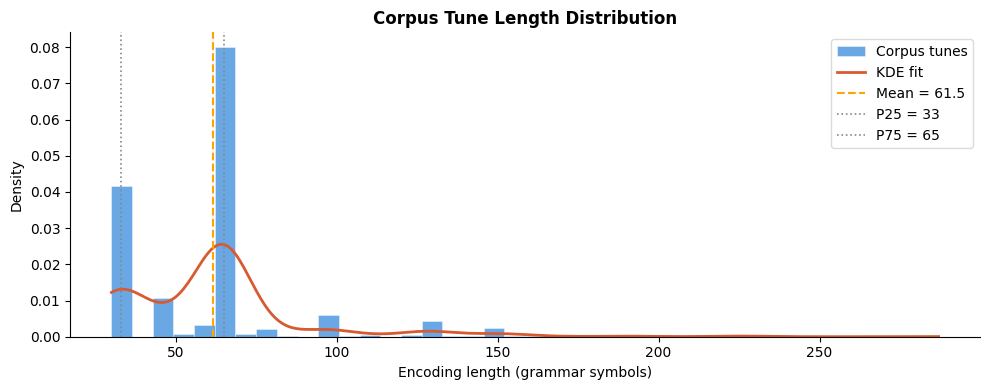

Min: 30  P25: 33  Median: 64  P75: 65  Max: 287  Mean: 61.5  Std: 28.7


In [11]:
# Tune length distribution with corpus KDE
corpus_lengths = calibration.get('corpus_lengths', [])

if corpus_lengths:
    from scipy.stats import gaussian_kde

    lengths = np.array(corpus_lengths)
    kde = gaussian_kde(lengths, bw_method=0.3)
    x_grid = np.linspace(lengths.min(), lengths.max(), 400)
    kde_curve = kde(x_grid)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(lengths, bins=40, density=True, color='#378ADD', alpha=0.75,
            edgecolor='white', linewidth=0.4, label='Corpus tunes')
    ax.plot(x_grid, kde_curve, color='#D85A30', linewidth=2.0, label='KDE fit')
    ax.axvline(lengths.mean(), color='orange', linestyle='--', linewidth=1.5,
               label=f'Mean = {lengths.mean():.1f}')

    # Annotate key percentiles
    for pct, ls in [(25, ':'), (75, ':')]:
        v = np.percentile(lengths, pct)
        ax.axvline(v, color='#888', linestyle=ls, linewidth=1.2, label=f'P{pct} = {v:.0f}')

    ax.set_xlabel('Encoding length (grammar symbols)')
    ax.set_ylabel('Density')
    ax.set_title('Corpus Tune Length Distribution', fontweight='bold')
    ax.legend(framealpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('plots/length_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Min: {lengths.min():.0f}  P25: {np.percentile(lengths,25):.0f}  "
          f"Median: {np.median(lengths):.0f}  P75: {np.percentile(lengths,75):.0f}  "
          f"Max: {lengths.max():.0f}  Mean: {lengths.mean():.1f}  Std: {lengths.std():.1f}")
else:
    print("corpus_lengths not in calibration — re-run cell 18 first.")


In [12]:
# bring that in the thesis

import pandas as pd

df = pd.read_csv('irish_npc_results.csv')
print(df['encoding_length'].describe())
print("\nTop 20 most common lengths:")
print(df['encoding_length'].value_counts().head(20))


count    1195.000000
mean       61.490377
std        28.708415
min        30.000000
25%        33.000000
50%        64.000000
75%        65.000000
max       287.000000
Name: encoding_length, dtype: float64

Top 20 most common lengths:
encoding_length
65     372
64     197
32     158
33     139
48      52
49      25
97      24
63      22
66      18
128     14
62      13
129     12
96      12
150     11
31      10
34       9
80       9
61       7
98       6
151      6
Name: count, dtype: int64


In [13]:
# =============================================================================
# Fitness Functions
# =============================================================================

def compute_npc(music_data: dict) -> dict:
    """
    Compute NPC using the same pipeline as the corpus, plus HO/AU costs.
    Returns dict with 'npc' and 'encoding_length'.
    """
    chunks = music_data['chunks']
    ho_p = {k: {"base_segment": v} for k, v in music_data.get('ho_patterns', {}).items()}
    au_p = music_data.get('au_patterns', {})
    grammar_rules = music_data['grammar']
    result = decode(grammar_rules, chunks, ho_patterns=ho_p, au_patterns=au_p, start="p_0")
    chunk_list = result['chunk_data']
    
    if not chunk_list:
        return {'npc': 0.0, 'encoding_length': 0}
    
    encoding, motifs, unique_chunks = encode_chunks_incremental(chunk_list, VAR_FUNCS)
    calc = NPCCalculator()
    npc_result = calc.calculate_npc(encoding, motifs, unique_chunks)
    total = float(npc_result['total'])
    enc_len = len(encoding)
    
    # HO pattern cost
    ho_patterns = music_data.get('ho_patterns', {})
    seen_ho_funcs = set()
    seen_ho_params = {}
    for rule_rhs in grammar_rules.values():
        for sym in rule_rhs:
            for ho_name in ho_patterns:
                if ho_name not in sym:
                    continue
                if sym.startswith(('T(', 'A(', 'D(')) and ho_name in sym:
                    func = sym[0]
                    parts = sym[2:-1].split(',')
                    if len(parts) >= 2:
                        param = parts[-1].strip()
                        key = f"{func}:{param}"
                        if key not in seen_ho_params:
                            seen_ho_params[key] = True
                            total += 1
                elif sym.startswith(('G(', 'I(', 'R(')) and ho_name in sym:
                    func = sym[0]
                    if func not in seen_ho_funcs:
                        seen_ho_funcs.add(func)
                        total += 1
    
    # AU pattern cost
    au_patterns = music_data.get('au_patterns', {})
    for name, info in au_patterns.items():
        total += len(info.get('variables', []))
    
    return {'npc': total, 'encoding_length': enc_len}


def complexity_score(npc_value: float, corpus_mean: float, corpus_std: float) -> float:
    """Gaussian fallback: 1.0 at corpus mean, exp(-0.5 * z^2). Used only when KDE unavailable."""
    if corpus_std <= 0: corpus_std = 1.0
    z = (npc_value - corpus_mean) / corpus_std
    return math.exp(-0.5 * z * z)


class KDEScorer:
    """Score NPC values using KDE on length-adjusted residuals from corpus."""
    def __init__(self, npc_residuals, poly_coeffs):
        from scipy.stats import gaussian_kde
        self.kde = gaussian_kde(npc_residuals)
        self.poly = np.poly1d(poly_coeffs)
        x_grid = np.linspace(min(npc_residuals), max(npc_residuals), 500)
        self.max_density = self.kde(x_grid).max()

    def score(self, npc_value, encoding_length):
        """Score: is this tune's NPC typical for its length?"""
        predicted = self.poly(encoding_length)
        residual = npc_value - predicted
        density = float(self.kde(residual))
        return min(density / self.max_density, 1.0)


class LengthScorer:
    """Score encoding length against corpus distribution using KDE."""
    def __init__(self, corpus_lengths):
        from scipy.stats import gaussian_kde
        self.kde = gaussian_kde(corpus_lengths, bw_method=0.3)
        x_grid = np.linspace(min(corpus_lengths), max(corpus_lengths), 500)
        self.max_density = self.kde(x_grid).max()

    def score(self, encoding_length):
        if encoding_length <= 0:
            return 0.0
        density = float(self.kde(encoding_length))
        return min(density / self.max_density, 1.0)


def get_bar_info(time_sig: str) -> dict:
    """Bar length and bin count per time signature."""
    ts_map = {
        '4/4': {'bar_length': 4.0, 'bins': 16}, '3/4': {'bar_length': 3.0, 'bins': 12},
        '2/4': {'bar_length': 2.0, 'bins': 8},  '6/8': {'bar_length': 3.0, 'bins': 12},
        '9/8': {'bar_length': 4.5, 'bins': 18}, '12/8': {'bar_length': 6.0, 'bins': 24},
    }
    info = ts_map.get(time_sig, ts_map['4/4'])
    info['time_sig'] = time_sig
    return info


def compute_rhythm_histogram(melody, time_sig='4/4'):
    """Normalised onset histogram within one bar at 16th-note resolution."""
    bar_info = get_bar_info(time_sig)
    bar_length, bins = bar_info['bar_length'], bar_info['bins']
    if not melody: return tuple([0.0] * bins)
    histogram = [0.0] * bins
    current_time = 0.0
    for pitch, duration in melody:
        bar_pos = current_time % bar_length
        histogram[int((bar_pos / bar_length) * bins) % bins] += 1
        current_time += duration
    total = sum(histogram)
    if total > 0: histogram = [h / total for h in histogram]
    return tuple(histogram)


def cosine_similarity(a, b):
    """Cosine similarity between two vectors."""
    dot = sum(x * y for x, y in zip(a, b))
    na = math.sqrt(sum(x*x for x in a))
    nb = math.sqrt(sum(x*x for x in b))
    return dot / (na * nb) if na > 0 and nb > 0 else 0.0


def rhythm_score(melody_histogram, pattern_tables, time_sig, k=5):
    """KNN rhythm scoring: mean cosine similarity to k nearest corpus patterns."""
    table = pattern_tables.get(time_sig, {})
    if not table: return {'knn_mean': 0.5, 'knn_sims': []}
    sims = sorted(
        [cosine_similarity(melody_histogram, pat) for pat in table.keys()],
        reverse=True
    )
    top_k = sims[:min(k, len(sims))]
    return {'knn_mean': sum(top_k) / len(top_k), 'knn_sims': top_k}


class FitnessEvaluator:
    """Weighted sum of rhythm (KNN), length (KDE), and complexity (KDE) scores.
    Default weights: rhythm=0.5, length=0.3, complexity=0.2."""
    def __init__(self, calibration, w_complexity=0.3, w_rhythm=0.4, w_length=0.3, k=5):
        self.calibration = calibration
        self.w_complexity = w_complexity
        self.w_rhythm = w_rhythm
        self.w_length = w_length
        self.k = k
        residuals = calibration.get('npc_residuals', [])
        poly_coeffs = calibration.get('npc_poly_coeffs', None)
        self.kde_scorer = KDEScorer(residuals, poly_coeffs) if residuals and poly_coeffs else None
        corpus_lengths = calibration.get('corpus_lengths', [])
        self.length_scorer = LengthScorer(corpus_lengths) if corpus_lengths else None

    def evaluate(self, melody, music_data=None, time_sig='4/4'):
        try:
            if music_data:
                npc_result = compute_npc(music_data)
                npc = npc_result['npc']
                enc_len = npc_result['encoding_length']
            else:
                npc, enc_len = -1.0, 0
            if npc >= 0 and self.kde_scorer:
                c_score = self.kde_scorer.score(npc, enc_len)
            elif npc >= 0:
                c_score = complexity_score(npc, self.calibration['npc_mean'], self.calibration['npc_std'])
            else:
                c_score = 0.0
        except Exception:
            npc, enc_len, c_score = -1.0, 0, 0.0
        l_score = self.length_scorer.score(enc_len) if self.length_scorer and enc_len > 0 else 0.5
        hist = compute_rhythm_histogram(melody, time_sig=time_sig)
        r_result = rhythm_score(hist, self.calibration['pattern_tables'], time_sig, k=self.k)
        r_score = r_result['knn_mean']
        tw = self.w_complexity + self.w_rhythm + self.w_length
        total = (self.w_complexity * c_score + self.w_rhythm * r_score + self.w_length * l_score) / tw if tw > 0 else 0.0
        return {'total': total, 'complexity': c_score, 'rhythm': r_score, 'length': l_score,
                'knn_sims': r_result['knn_sims'], 'npc_value': npc, 'encoding_length': enc_len}

print("Fitness functions defined.")

Fitness functions defined.


In [20]:
# === Fitness Tracker ===
class FitnessTracker:
    """Records every fitness evaluation for post-run analysis."""
    def __init__(self, pop_size=50):
        self.pop_size = pop_size
        self.reset()

    def reset(self, pop_size=None):
        self.records = []
        if pop_size is not None:
            self.pop_size = pop_size

    def log(self, total, complexity, length, rhythm, enc_len, npc):
        self.records.append({
            'call': len(self.records),
            'total': total, 'complexity': complexity,
            'length': length, 'rhythm': rhythm,
            'enc_len': enc_len, 'npc': npc,
        })

    def to_dataframe(self):
        import pandas as pd
        df = pd.DataFrame(self.records)
        if not df.empty:
            df['generation'] = df['call'] // self.pop_size
        return df

    def generation_summary(self, history=None):
        import pandas as pd
        df = self.to_dataframe()
        if df.empty:
            return df
        if history is not None and len(history) > 0:
            # Use PTO's history (best total per generation) to track which
            # individual set the best-ever score at each generation end.
            # This avoids the wrong df['call']//pop_size windowing.
            rows = []
            best_comp = {'complexity': 0.0, 'rhythm': 0.0, 'length': 0.0}
            n = len(df)
            for g, best_total in enumerate(history):
                matches = df[abs(df['total'] - best_total) < 1e-9]
                if not matches.empty:
                    r = matches.iloc[0]
                    best_comp = {'complexity': r['complexity'],
                                 'rhythm': r['rhythm'], 'length': r['length']}
                end = max(1, int((g + 1) / len(history) * n))
                sl = df.iloc[:end]
                rows.append({
                    'generation': g,
                    'best_total': best_total,
                    'best_complexity': best_comp['complexity'],
                    'best_rhythm': best_comp['rhythm'],
                    'best_length': best_comp['length'],
                    'mean_total': sl['total'].mean(),
                    'mean_complexity': sl['complexity'].mean(),
                    'mean_rhythm': sl['rhythm'].mean(),
                    'mean_length': sl['length'].mean(),
                })
            return pd.DataFrame(rows)
        # Fallback: approximate windowing when history is unavailable
        return df.groupby('generation').agg(
            best_total=('total', 'max'),
            mean_total=('total', 'mean'),
            best_complexity=('complexity', 'max'),
            mean_complexity=('complexity', 'mean'),
            best_length=('length', 'max'),
            mean_length=('length', 'mean'),
            best_rhythm=('rhythm', 'max'),
            mean_rhythm=('rhythm', 'mean'),
        ).reset_index()


tracker = FitnessTracker(pop_size=50)
evaluator = FitnessEvaluator(calibration, w_complexity=0.2, w_rhythm=0.5, w_length=0.3)

def fitness(music_data):
    """Fitness function for PTO. Higher is better."""
    try:
        melody = expand_music_data(music_data)
    except Exception:
        tracker.log(0.0, 0.0, 0.0, 0.0, 0, -1.0)
        return 0.0
    if not melody:
        tracker.log(0.0, 0.0, 0.0, 0.0, 0, -1.0)
        return 0.0
    time_sig = music_data.get('time_sig', '4/4')
    result = evaluator.evaluate(melody, music_data=music_data, time_sig=time_sig)
    tracker.log(result['total'], result['complexity'], result['length'],
                result['rhythm'], result['encoding_length'], result['npc_value'])
    return result['total']

# Test
score = fitness(test_data)
print(f"Test tune fitness: {score:.4f}")
result = evaluator.evaluate(test_melody, music_data=test_data, time_sig=test_data['time_sig'])
print(f"  Complexity:     {result['complexity']:.4f} (NPC={result['npc_value']:.1f})")
print(f"  Length:         {result['length']:.4f} (enc_len={result['encoding_length']})")
print(f"  Rhythm (KNN-5): {result['rhythm']:.4f}  sims={[round(s,3) for s in result['knn_sims']]}")


Test tune fitness: 0.4687
  Complexity:     0.9621 (NPC=160.0)
  Length:         0.1265 (enc_len=84)
  Rhythm (KNN-5): 0.4767  sims=[0.715, 0.429, 0.414, 0.413, 0.412]


/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_49976/342219056.py:78: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  density = float(self.kde(residual))
/var/folders/cf/ncs9r77x78199vwpl1842v3w0000gn/T/ipykernel_49976/342219056.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  density = float(self.kde(encoding_length))


## 5. Evolution with PTO

PTO's Genetic Algorithm evolves program traces. Crossover and mutation operate on the 
flat trace of `rnd` decisions; replay through the generator produces new music structures.

In [22]:
POP_SIZE   = 30
N_GEN      = 20

tracker.reset(pop_size=POP_SIZE)

(best_pheno_ga, best_geno_ga), best_fx_ga, history = run(
    generate, fitness, better=max,
    Solver='genetic_algorithm',
    solver_args={'n_generation': N_GEN, 'population_size': POP_SIZE, 'return_history': True}
)

print(f"\nBest fitness: {best_fx_ga:.4f}")
best_melody_ga = expand_music_data(best_pheno_ga)
print(f"Best melody: {len(best_melody_ga)} notes, time_sig={best_pheno_ga['time_sig']}")



Best fitness: 0.9985
Best melody: 134 notes, time_sig=4/4


In [23]:
result = evaluator.evaluate(best_melody_ga, music_data=best_pheno_ga, time_sig=best_pheno_ga['time_sig'])
print(f"Fitness breakdown:")
print(f"  Total:      {result['total']:.4f}")
print(f"  Complexity: {result['complexity']:.4f} (NPC={result['npc_value']:.1f}, enc_len={result['encoding_length']}, corpus mean={calibration['npc_mean']:.1f})")
print(f"  Rhythm (KNN-5): {result['rhythm']:.4f}")
print(f"    Top-5 sims: {[round(s,3) for s in result['knn_sims']]}")
print(f"\nStructure:")
print(f"  Chunks: {len(best_pheno_ga['chunks'])}, HO: {len(best_pheno_ga['ho_patterns'])}")
for rule, rhs in best_pheno_ga['grammar'].items():
    print(f"  {rule} -> {' '.join(str(s) for s in rhs)}")

Fitness breakdown:
  Total:      0.9985
  Complexity: 0.9981 (NPC=120.0, enc_len=64, corpus mean=138.6)
  Rhythm (KNN-5): 0.9979
    Top-5 sims: [0.999, 0.998, 0.998, 0.998, 0.997]

Structure:
  Chunks: 6, HO: 1
  p_0 -> p_1 p_2 p_2 p_1
  p_1 -> f_1(c_4,-2) p_3 f_1(c_0,2) T(ho_0,-3) c_1
  p_2 -> c_2 P(c_0,0,3) p_4 p_4
  p_3 -> T(c_3,5) p_5 p_5 T(c_0,3)
  p_4 -> T(c_3,-5) T(c_3,-2) T(c_1,-5) H(c_0,0,1) c_3
  p_5 -> T(c_0,-5) T(c_1,5) c_1 c_1


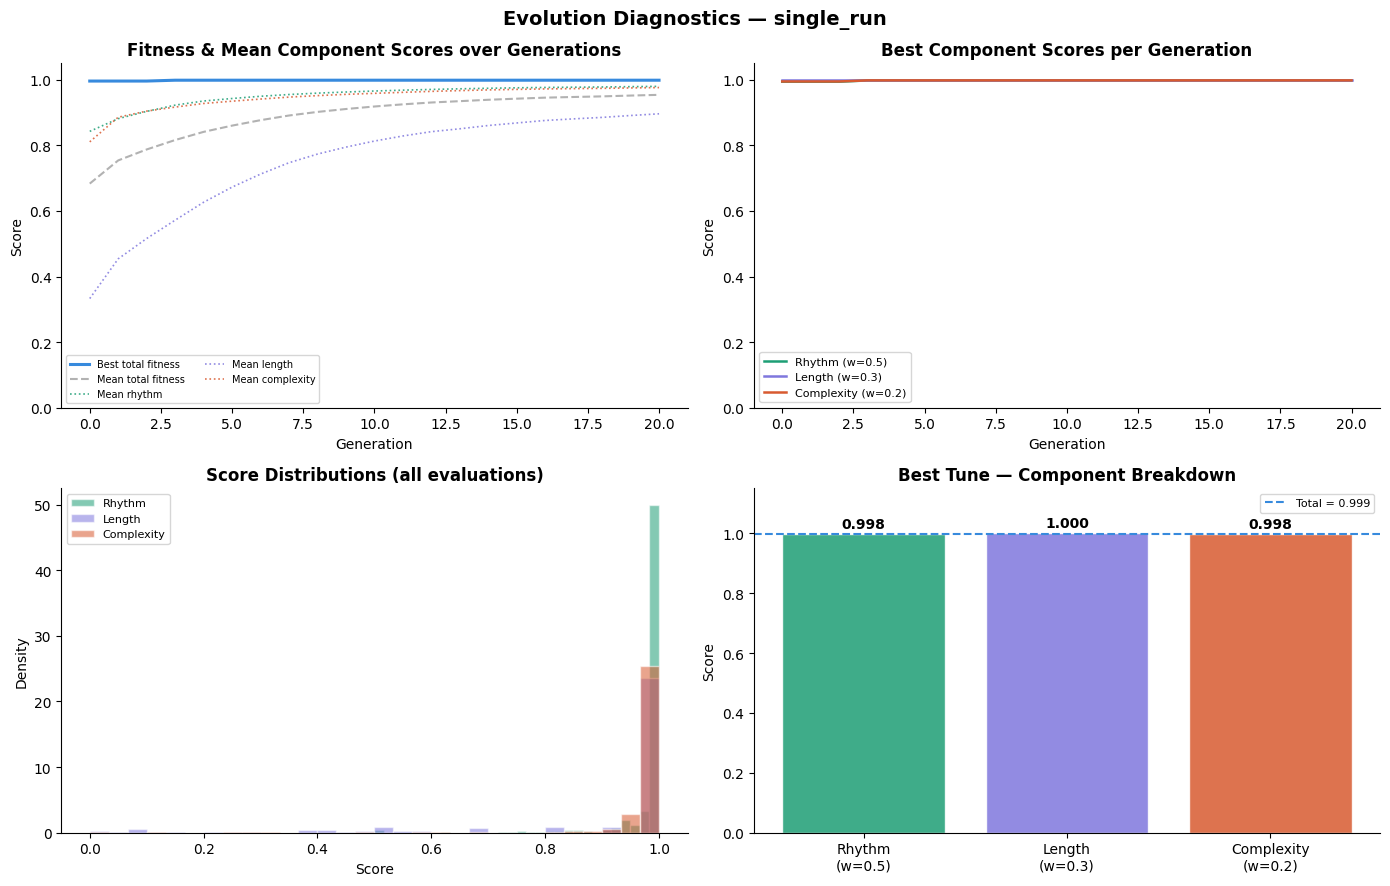

Saved: plots/evolution_single_run.png


,generation,best_total,best_complexity,best_rhythm,best_length,mean_total,mean_complexity,mean_rhythm,mean_length
0,0,0.995974,0.994687,0.994072,1.0,0.683281,0.810591,0.842604,0.332869
1,1,0.995974,0.994687,0.994072,1.0,0.754009,0.885739,0.881328,0.453990
2,2,0.995974,0.994687,0.994072,1.0,0.787392,0.904345,0.903493,0.515922
3,3,0.998549,0.998068,0.997871,1.0,0.816148,0.916620,0.922558,0.571816
4,4,0.998549,0.998068,0.997871,1.0,0.841028,0.927608,0.935149,0.626442
5,5,0.998549,0.998068,0.997871,1.0,0.860087,0.934632,0.942768,0.672590
6,6,0.998549,0.998068,0.997871,1.0,0.876700,0.941089,0.949592,0.712287
7,7,0.998549,0.998068,0.997871,1.0,0.890932,0.947013,0.954902,0.746927
8,8,0.998549,0.998068,0.997871,1.0,0.901875,0.951541,0.959145,0.773315
9,9,0.998549,0.998068,0.997871,1.0,0.910722,0.955420,0.962548,0.794547


In [25]:
def plot_evolution(history, tracker, run_label='', save_prefix='plots/evolution'):
    """Four-panel evolution diagnostic: fitness curve, per-component curves,
    score distributions, and best-tune breakdown."""
    gen_df = tracker.generation_summary(history=history)
    all_df = tracker.to_dataframe()

    COLORS = {'rhythm': '#1D9E75', 'length': '#7F77DD', 'complexity': '#D85A30',
              'total': '#378ADD', 'mean': '#AAAAAA'}

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    title = f'Evolution Diagnostics — {run_label}' if run_label else 'Evolution Diagnostics'
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Panel 1: overall fitness + mean per-component over generations
    ax = axes[0, 0]
    if history:
        ax.plot(range(len(history)), history, color=COLORS['total'],
                linewidth=2.2, label='Best total fitness')
    if not gen_df.empty:
        ax.plot(gen_df['generation'], gen_df['mean_total'],
                color=COLORS['mean'], linewidth=1.5, linestyle='--',
                alpha=0.9, label='Mean total fitness')
        ax.plot(gen_df['generation'], gen_df['mean_rhythm'],
                color=COLORS['rhythm'], linewidth=1.2, linestyle=':',
                alpha=0.85, label='Mean rhythm')
        ax.plot(gen_df['generation'], gen_df['mean_length'],
                color=COLORS['length'], linewidth=1.2, linestyle=':',
                alpha=0.85, label='Mean length')
        ax.plot(gen_df['generation'], gen_df['mean_complexity'],
                color=COLORS['complexity'], linewidth=1.2, linestyle=':',
                alpha=0.85, label='Mean complexity')
    ax.set_xlabel('Generation'); ax.set_ylabel('Score')
    ax.set_title('Fitness & Mean Component Scores over Generations', fontweight='bold')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7, ncol=2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Panel 2: per-component best per generation
    ax = axes[0, 1]
    if not gen_df.empty:
        ax.plot(gen_df['generation'], gen_df['best_rhythm'],
                color=COLORS['rhythm'], linewidth=1.8, label='Rhythm (w=0.5)')
        ax.plot(gen_df['generation'], gen_df['best_length'],
                color=COLORS['length'], linewidth=1.8, label='Length (w=0.3)')
        ax.plot(gen_df['generation'], gen_df['best_complexity'],
                color=COLORS['complexity'], linewidth=1.8, label='Complexity (w=0.2)')
    ax.set_xlabel('Generation'); ax.set_ylabel('Score')
    ax.set_title('Best Component Scores per Generation', fontweight='bold')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Panel 3: distributions of all evaluations
    ax = axes[1, 0]
    if not all_df.empty:
        valid = all_df[all_df['total'] > 0]
        for col, label, color in [
            ('rhythm',     'Rhythm',     COLORS['rhythm']),
            ('length',     'Length',     COLORS['length']),
            ('complexity', 'Complexity', COLORS['complexity']),
        ]:
            ax.hist(valid[col], bins=30, alpha=0.55, color=color,
                    label=label, density=True, edgecolor='white')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.set_title('Score Distributions (all evaluations)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Panel 4: best-tune component breakdown
    ax = axes[1, 1]
    if not all_df.empty:
        best_row = all_df.loc[all_df['total'].idxmax()]
        labels  = ['Rhythm\n(w=0.5)', 'Length\n(w=0.3)', 'Complexity\n(w=0.2)']
        scores  = [best_row['rhythm'], best_row['length'], best_row['complexity']]
        colors  = [COLORS['rhythm'], COLORS['length'], COLORS['complexity']]
        bars = ax.bar(labels, scores, color=colors, alpha=0.85, edgecolor='white')
        for bar, s in zip(bars, scores):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                    f'{s:.3f}', ha='center', fontsize=10, fontweight='bold')
        ax.axhline(best_row['total'], color=COLORS['total'], linestyle='--',
                   linewidth=1.5, label=f"Total = {best_row['total']:.3f}")
        ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
        ax.set_title('Best Tune — Component Breakdown', fontweight='bold')
        ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    plt.tight_layout()
    suffix = ('_' + run_label.replace(' ', '_')) if run_label else ''
    fname = f'{save_prefix}{suffix}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")
    return gen_df


# Plot the single run just completed
plot_evolution(history, tracker, run_label='single_run')



Evolution run 1/20
Saved MIDI file: evolved_tunes/evolved_00.mid


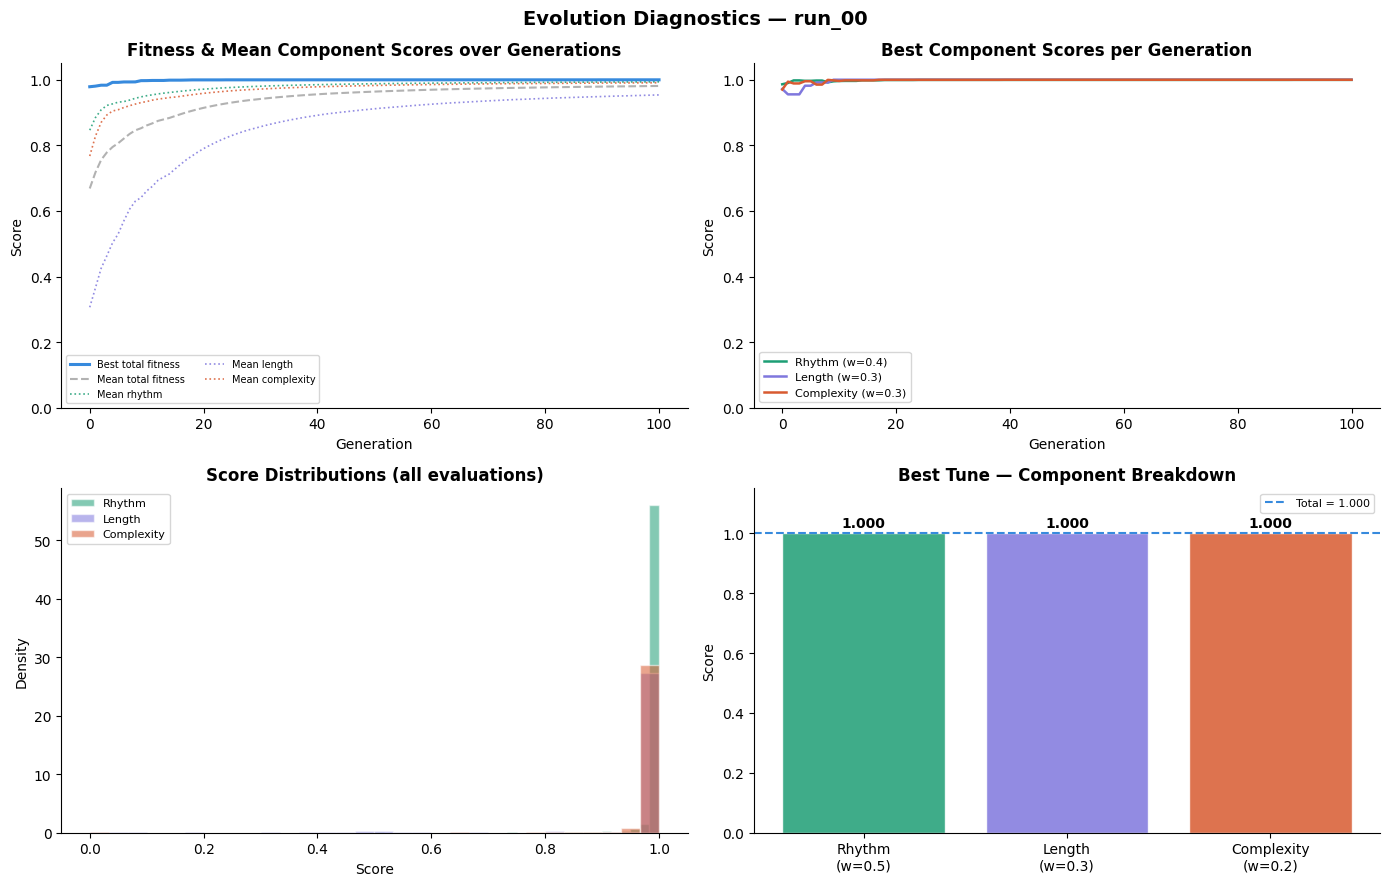

Saved: plots/evolution_run_00.png
  -> 226 notes, 6/8, fitness=1.000 (R=1.000, L=1.000, C=1.000, NPC=122)

Evolution run 2/20
Saved MIDI file: evolved_tunes/evolved_01.mid


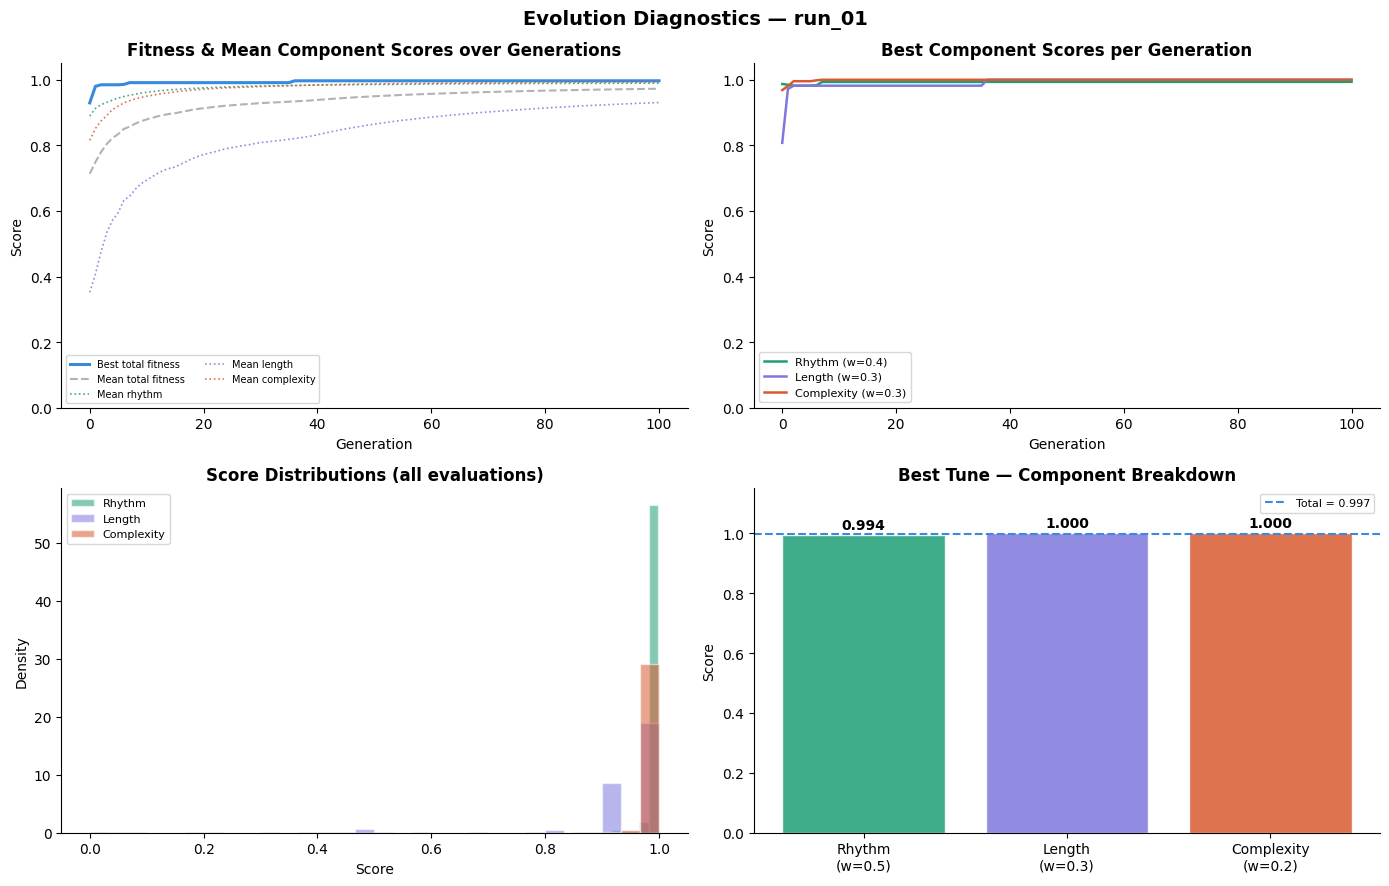

Saved: plots/evolution_run_01.png
  -> 362 notes, 2/4, fitness=0.997 (R=0.994, L=1.000, C=1.000, NPC=122)

Evolution run 3/20


KeyboardInterrupt: 

In [47]:
# Run PTO GA 20 times, save best evolved tune from each run
os.makedirs('evolved_tunes', exist_ok=True)

scale = [0, 2, 3, 5, 7, 9, 11]
evolved_results = []

for i in range(20):
    print(f"\n{'='*50}")
    print(f"Evolution run {i+1}/20")
    print(f"{'='*50}")

    POP_SIZE = 50
    tracker.reset(pop_size=POP_SIZE)   # clear tracker for this run

    try:
        (pheno, geno), fx, hist = run(
            generate, fitness, better=max,
            Solver='genetic_algorithm',
            solver_args={'n_generation': 100, 'population_size': POP_SIZE, 'return_history': True}
        )

        melody = expand_music_data(pheno)
        ts = pheno.get('time_sig', '4/4')
        result = evaluator.evaluate(melody, music_data=pheno, time_sig=ts)

        # Save MIDI
        midi_melody = []
        for p, d in melody:
            midi_pitch = 60 + (p // 7) * 12 + scale[p % 7]
            midi_melody.append((midi_pitch, int(round(d * 480))))
        filename = f'evolved_tunes/evolved_{i:02d}.mid'
        decoder.save_melody_to_midi(midi_melody, filename, ticks_per_beat=480, tempo_bpm=120)

        # Save tracker snapshot for this run
        run_df = tracker.to_dataframe()
        run_df['run'] = i
        run_df.to_csv(f'evolved_tunes/tracker_run_{i:02d}.csv', index=False)

        # Save evolution diagnostic plot
        plot_evolution(hist, tracker, run_label=f'run_{i:02d}',
                       save_prefix='plots/evolution')

        evolved_results.append({
            'id': i, 'notes': len(melody), 'ts': ts,
            'total': result['total'], 'complexity': result['complexity'],
            'rhythm': result['rhythm'], 'length': result['length'],
            'npc': result['npc_value'], 'enc_len': result['encoding_length'],
            'history': hist,
        })

        print(f"  -> {len(melody)} notes, {ts}, fitness={result['total']:.3f} "
              f"(R={result['rhythm']:.3f}, L={result['length']:.3f}, "
              f"C={result['complexity']:.3f}, NPC={result['npc_value']:.0f})")

    except Exception as e:
        print(f"  -> Failed: {e}")

# Summary table
print(f"\n{'='*50}")
print(f"SUMMARY: {len(evolved_results)}/20 successful runs")
print(f"{'='*50}")
if evolved_results:
    import pandas as pd
    summary_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'history'}
                                for r in evolved_results])
    print(summary_df[['id','ts','notes','enc_len','total','rhythm','length','complexity','npc']].to_string(index=False))
    print(f"\nMeans — total={summary_df['total'].mean():.3f}, "
          f"rhythm={summary_df['rhythm'].mean():.3f}, "
          f"length={summary_df['length'].mean():.3f}, "
          f"complexity={summary_df['complexity'].mean():.3f}")
    summary_df.to_csv('evolved_tunes/run_summary.csv', index=False)
    print("Saved run_summary.csv")


## 6. Analysis & Export

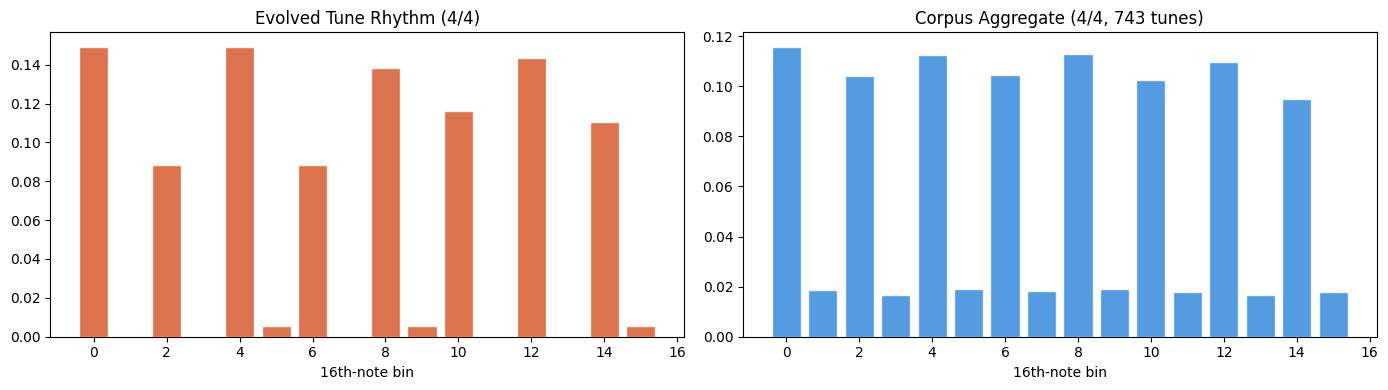

Cosine similarity to corpus aggregate: 0.9768


In [191]:
ts = best_pheno_ga['time_sig']
hist = compute_rhythm_histogram(best_melody_ga, time_sig=ts)
table = calibration['pattern_tables'].get(ts, {})
if table:
    n_bins = len(next(iter(table)))
    agg = [0.0] * n_bins
    total = sum(table.values())
    for pat, count in table.items():
        for i, v in enumerate(pat): agg[i] += v * count
    s = sum(agg)
    if s > 0: agg = [v / s for v in agg]
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].bar(range(len(hist)), hist, color='#D85A30', alpha=0.85, edgecolor='white')
    axes[0].set_title(f"Evolved Tune Rhythm ({ts})"); axes[0].set_xlabel("16th-note bin")
    axes[1].bar(range(len(agg)), agg, color='#378ADD', alpha=0.85, edgecolor='white')
    axes[1].set_title(f"Corpus Aggregate ({ts}, {total} tunes)"); axes[1].set_xlabel("16th-note bin")
    plt.tight_layout()
    plt.savefig('plots/rhythm_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Cosine similarity to corpus aggregate: {cosine_similarity(tuple(hist), tuple(agg)):.4f}")
else:
    print(f"No corpus data for {ts}")

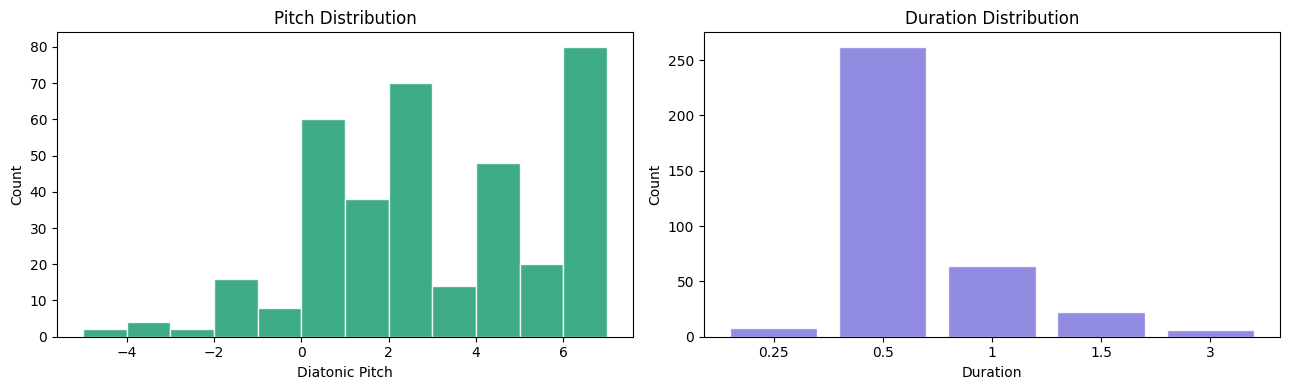

Pitch range: -5 to 6 (11 degrees)
Total duration: 248.0 beats, Unique durations: 5


In [192]:
pitches = [p for p, d in best_melody_ga]
durations = [d for p, d in best_melody_ga]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(pitches, bins=range(min(pitches), max(pitches)+2), color='#1D9E75', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Diatonic Pitch'); axes[0].set_ylabel('Count'); axes[0].set_title('Pitch Distribution')
dur_counts = Counter(durations)
durs_sorted = sorted(dur_counts.keys())
axes[1].bar([str(d) for d in durs_sorted], [dur_counts[d] for d in durs_sorted], color='#7F77DD', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Duration'); axes[1].set_ylabel('Count'); axes[1].set_title('Duration Distribution')
plt.tight_layout()
plt.savefig('plots/pitch_duration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Pitch range: {min(pitches)} to {max(pitches)} ({max(pitches)-min(pitches)} degrees)")
print(f"Total duration: {sum(durations):.1f} beats, Unique durations: {len(dur_counts)}")

In [193]:
def save_to_midi(melody, filename, base_note=60):
    scale = [0, 2, 3, 5, 7, 9, 11]
    midi_melody = []
    for p, d in melody:
        midi_pitch = base_note + (p // 7) * 12 + scale[p % 7]
        midi_melody.append((midi_pitch, int(round(d * 480))))
    decoder.save_melody_to_midi(midi_melody, filename, ticks_per_beat=480, tempo_bpm=120)

save_to_midi(best_melody_ga, 'evolved_irish.mid')
print(f"Saved evolved_irish.mid ({len(best_melody_ga)} notes)")

Saved MIDI file: evolved_irish.mid
Saved evolved_irish.mid (362 notes)


## 7. PTO Performance Test

Running PTO on flat generator (30 pop, 20 gen)...
Flat generator best fitness: 0.9968


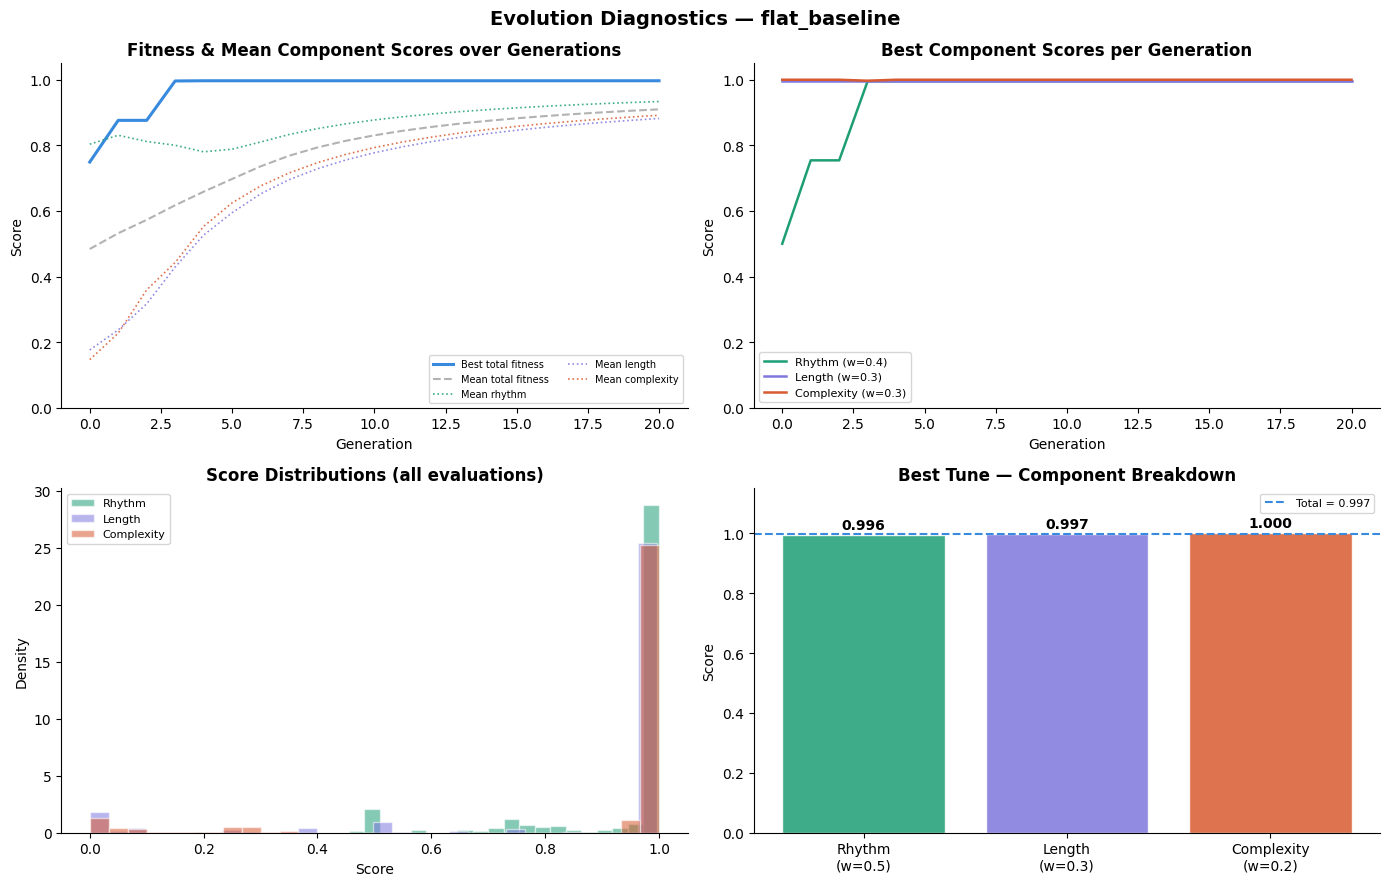

Saved: plots/evolution_flat_baseline.png


,generation,best_total,best_complexity,best_rhythm,best_length,mean_total,mean_complexity,mean_rhythm,mean_length
0,0,0.749048,1.000000,0.500000,0.996826,0.483938,0.146598,0.803526,0.176185
1,1,0.876161,1.000000,0.754226,0.996826,0.531932,0.227279,0.830693,0.237098
2,2,0.876161,1.000000,0.754226,0.996826,0.572766,0.359331,0.811712,0.316814
3,3,0.996252,0.997012,0.995604,0.996826,0.617354,0.442714,0.800232,0.428983
4,4,0.996850,1.000000,0.995604,0.996826,0.658559,0.552713,0.780265,0.526279
5,5,0.996850,1.000000,0.995604,0.996826,0.697379,0.624517,0.788231,0.594533
6,6,0.996850,1.000000,0.995604,0.996826,0.735813,0.676011,0.810019,0.652004
7,7,0.996850,1.000000,0.995604,0.996826,0.768152,0.715635,0.832986,0.695106
8,8,0.996850,1.000000,0.995604,0.996826,0.793551,0.747172,0.851055,0.728631
9,9,0.996850,1.000000,0.995604,0.996826,0.813879,0.772443,0.865510,0.755450


In [46]:
# =============================================================================
# Flat Generator Baseline — PTO on a flat (uniform) generator
# =============================================================================

def generate_flat(pitch_range=(0, 7)):
    """Flat melody: same pitch/duration space as Seq++, no hierarchical structure.
    Matches Seq++ in feel probability (15% triplet), duration types, weights,
    and use_mask. Note count range (20-500) preserved from original baseline.
    Only difference from Seq++: no grammar reuse, no HO/AU patterns."""

    time_sig = rnd.choice(['4/4', '3/4', '2/4', '6/8', '9/8', '12/8'])
    feel = 'triplet' if rnd.random() < 0.15 else 'straight'

    if feel == 'straight':
        all_types = [(2, 10), (1, 30), (0.5, 40), (0.25, 20)]
    else:
        all_types = [(1, 30), (2/3, 20), (1/3, 60), (1/6, 20)]
    use_mask = [rnd.random() < 0.7 for _ in all_types]
    note_types = [t for t, use in zip(all_types, use_mask) if use]
    if not note_types:
        note_types = [all_types[rnd.randint(0, len(all_types) - 1)]]
    dur_vals = [d for d, _ in note_types]
    dur_wts  = [w for _, w in note_types]

    n_notes    = rnd.randint(20, 500)
    chunk_size = rnd.randint(1, 4)
    notes = [(rnd.randint(*pitch_range), rnd.choices(dur_vals, weights=dur_wts)[0])
             for _ in range(n_notes)]

    chunks, rhs = {}, []
    for ci, start in enumerate(range(0, n_notes, chunk_size)):
        key = f'c_{ci}'
        chunks[key] = notes[start:start + chunk_size]
        rhs.append(key)

    return {'chunks': chunks, 'ho_patterns': {}, 'au_patterns': {},
            'grammar': {'p_0': rhs}, 'time_sig': time_sig}

rand_tracker = FitnessTracker(pop_size=POP_SIZE)

def fitness_flat(music_data):
    try:
        melody = expand_music_data(music_data)
    except Exception:
        rand_tracker.log(0.0, 0.0, 0.0, 0.0, 0, -1.0)
        return 0.0
    if not melody:
        rand_tracker.log(0.0, 0.0, 0.0, 0.0, 0, -1.0)
        return 0.0
    time_sig = music_data.get('time_sig', '4/4')
    result = evaluator.evaluate(melody, music_data=music_data, time_sig=time_sig)
    rand_tracker.log(result['total'], result['complexity'], result['length'],
                     result['rhythm'], result['encoding_length'], result['npc_value'])
    return result['total']

print(f"Running PTO on flat generator ({POP_SIZE} pop, {N_GEN} gen)...")
rand_tracker.reset(pop_size=POP_SIZE)
(rand_best_pheno, _), rand_best_fx, rand_history = run(
    generate_flat, fitness_flat, better=max,
    Solver='genetic_algorithm',
    solver_args={'n_generation': N_GEN, 'population_size': POP_SIZE, 'return_history': True}
)
print(f"Flat generator best fitness: {rand_best_fx:.4f}")

plot_evolution(rand_history, rand_tracker, run_label='flat_baseline',
               save_prefix='plots/evolution')


In [ ]:
# Sample 100 flat generator outputs and evaluate them
import numpy as np
random_fitnesses = []
random_components = []
for _ in range(100):
    try:
        data = generate()
        melody = expand_music_data(data)
        if 40 <= len(melody) <= 120:
            result = evaluator.evaluate(melody, music_data=data, time_sig=data['time_sig'])
            random_fitnesses.append(result['total'])
            random_components.append((result['complexity'], result['rhythm']))
    except:
        pass

r = np.array(random_fitnesses)
c = np.array([x[0] for x in random_components])
rh = np.array([x[1] for x in random_components])
print(f"Flat generator fitness: mean={r.mean():.3f}, std={r.std():.3f}, min={r.min():.3f}, max={r.max():.3f}")
print(f"Flat generator complexity: mean={c.mean():.3f}, std={c.std():.3f}")
print(f"Flat generator rhythm: mean={rh.mean():.3f}, std={rh.std():.3f}")
print(f"Fraction with fitness > 0.9: {(r > 0.9).mean():.2%}")
print(f"Fraction with fitness > 0.95: {(r > 0.95).mean():.2%}")

Random fitness: mean=0.690, std=0.117, min=0.466, max=0.822
Random complexity: mean=0.910, std=0.143
Random rhythm: mean=0.839, std=0.167
Fraction with fitness > 0.9: 0.00%
Fraction with fitness > 0.95: 0.00%


Run 1/20: seq++=0.9918, flat=0.8047
Run 2/20: seq++=0.9989, flat=0.8230
Run 3/20: seq++=0.9951, flat=0.9878
Run 4/20: seq++=0.9865, flat=0.7957
Run 5/20: seq++=0.9974, flat=0.8468
Run 6/20: seq++=0.9959, flat=0.8098
Run 7/20: seq++=0.9964, flat=0.9724
Run 8/20: seq++=0.9970, flat=0.8324
Run 9/20: seq++=0.9938, flat=0.8242
Run 10/20: seq++=0.9918, flat=0.7625
Run 11/20: seq++=0.9967, flat=0.8428
Run 12/20: seq++=0.9902, flat=0.8678
Run 13/20: seq++=0.9969, flat=0.8864
Run 14/20: seq++=0.9911, flat=0.8299
Run 15/20: seq++=0.9861, flat=0.8666
Run 16/20: seq++=0.9907, flat=0.8275
Run 17/20: seq++=0.9953, flat=0.8521
Run 18/20: seq++=0.9977, flat=0.8867
Run 19/20: seq++=0.9988, flat=0.8205
Run 20/20: seq++=0.9975, flat=0.8436

Completed: Seq++ 20/20, Random 20/20


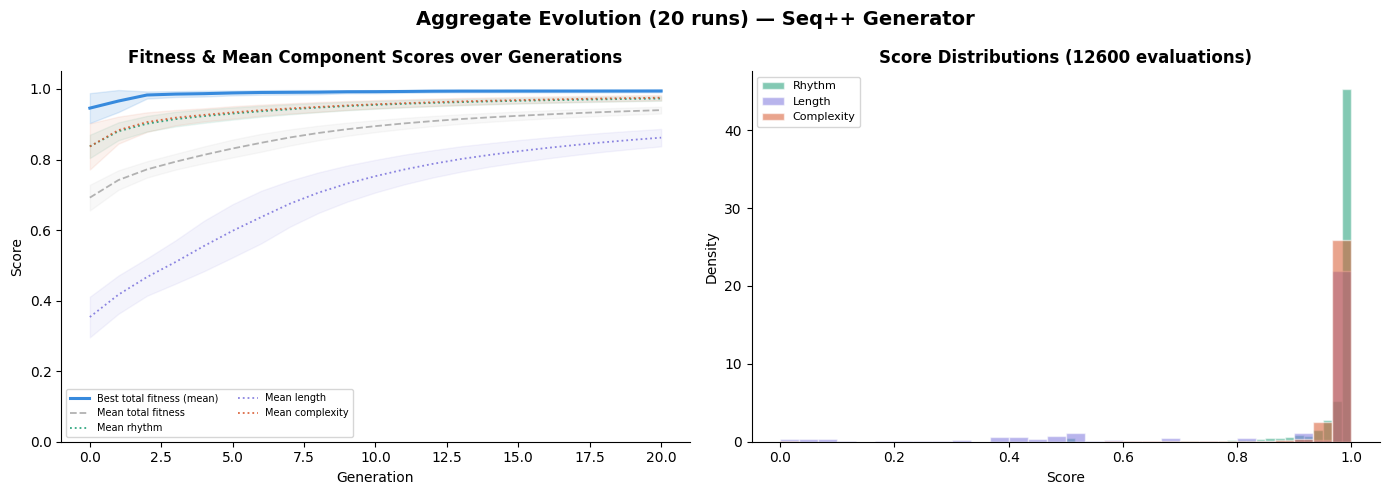

Saved: plots/aggregate_seqplusplus.png


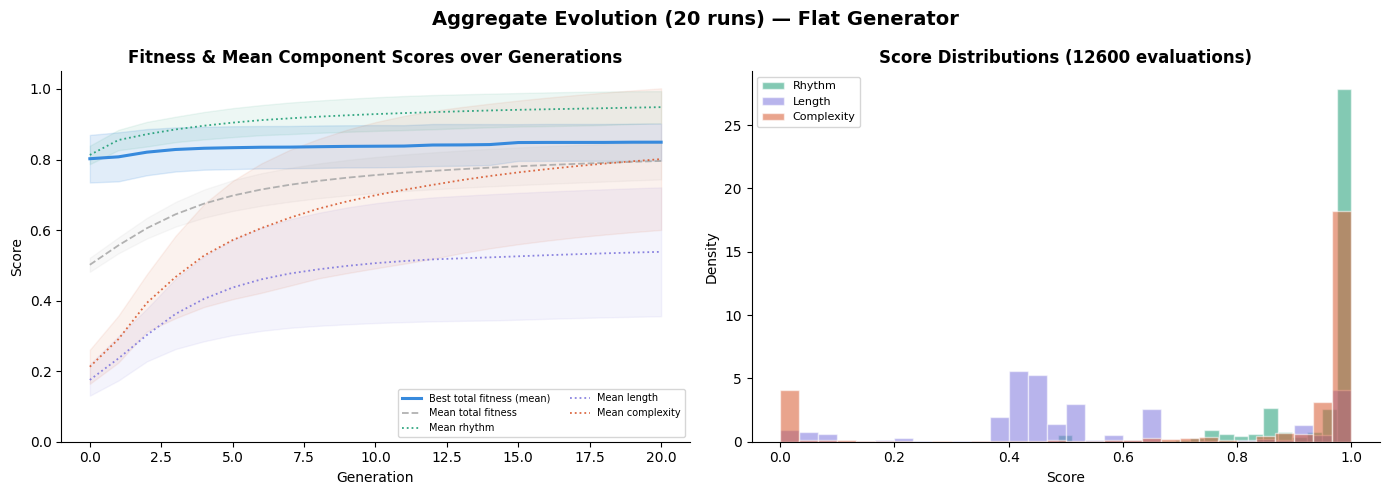

Saved: plots/aggregate_random.png

STATISTICAL COMPARISON (20 vs 20 runs)

Method                    Mean       Std       Min       Max    Median
----------------------------------------------------------------------
Seq++                   0.9943    0.0038    0.9861    0.9989    0.9956
Flat Generator          0.8492    0.0525    0.7625    0.9878    0.8376

Difference in mean: +0.1451

Welch's t-test:        t=12.0229, p=2.21e-10
Mann-Whitney U test:   U=398.0, p=9.17e-08
Cohen's d (effect size): 3.80  (large)


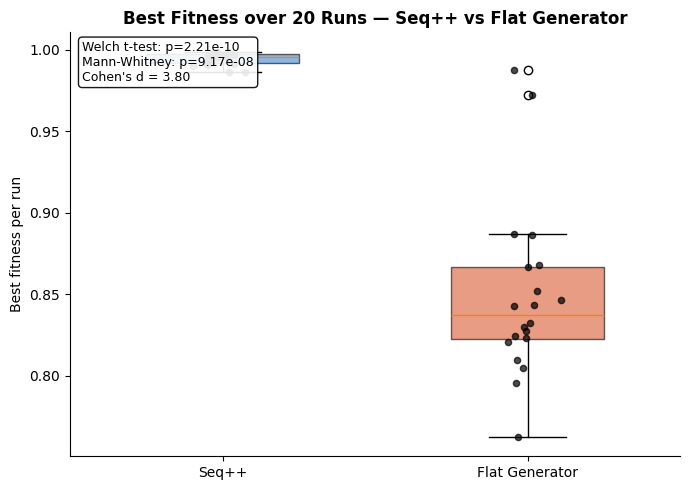

In [48]:
# =============================================================================
# Compare Seq++ vs Flat Generator — 20 runs each, pop=30, gen=20
# =============================================================================
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

N_RUNS = 20
POP_SIZE = 30
N_GEN = 20

def run_with_retry(gen_fn, fit_fn, max_attempts=5):
    """Retry PTO run on ValueError (randrange edge case)."""
    for _ in range(max_attempts):
        try:
            return run(gen_fn, fit_fn, better=max,
                       Solver='genetic_algorithm',
                       solver_args={'n_generation': N_GEN,
                                    'population_size': POP_SIZE,
                                    'return_history': True})
        except ValueError:
            continue
    return None

# --- Collect 20 runs for each method ---
seq_runs = {'history': [], 'gen_dfs': [], 'all_dfs': [], 'best': []}
rand_runs = {'history': [], 'gen_dfs': [], 'all_dfs': [], 'best': []}

for i in range(N_RUNS):
    # Seq++
    tracker.reset(pop_size=POP_SIZE)
    res = run_with_retry(generate, fitness)
    if res is not None:
        (_, _), best_fx, hist = res
        seq_runs['history'].append(hist)
        seq_runs['gen_dfs'].append(tracker.generation_summary(history=hist))
        seq_runs['all_dfs'].append(tracker.to_dataframe())
        seq_runs['best'].append(best_fx)
    
    # Random
    rand_tracker.reset(pop_size=POP_SIZE)
    res = run_with_retry(generate_flat, fitness_flat)
    if res is not None:
        (_, _), best_fx, hist = res
        rand_runs['history'].append(hist)
        rand_runs['gen_dfs'].append(rand_tracker.generation_summary(history=hist))
        rand_runs['all_dfs'].append(rand_tracker.to_dataframe())
        rand_runs['best'].append(best_fx)
    
    print(f"Run {i+1}/{N_RUNS}: seq++={seq_runs['best'][-1] if seq_runs['best'] else 'failed':.4f}"
          f", flat={rand_runs['best'][-1] if rand_runs['best'] else 'failed':.4f}")

print(f"\nCompleted: Seq++ {len(seq_runs['best'])}/{N_RUNS}, Random {len(rand_runs['best'])}/{N_RUNS}")


# --- Aggregate helpers ---
def aggregate_history(runs):
    """Stack best-fitness histories into (n_runs × n_gens) array, padding if needed."""
    max_len = max(len(h) for h in runs['history'])
    arr = np.full((len(runs['history']), max_len), np.nan)
    for i, h in enumerate(runs['history']):
        arr[i, :len(h)] = h
    return arr

def aggregate_gen_means(runs, col):
    """Stack per-generation mean component values across runs."""
    max_len = max(len(df) for df in runs['gen_dfs'])
    arr = np.full((len(runs['gen_dfs']), max_len), np.nan)
    for i, df in enumerate(runs['gen_dfs']):
        arr[i, :len(df)] = df[col].values
    return arr


# --- Plot function: one figure per method with both panels ---
COLORS = {'rhythm': '#1D9E75', 'length': '#7F77DD', 'complexity': '#D85A30',
          'total': '#378ADD', 'mean': '#AAAAAA'}

def plot_method_aggregate(runs, method_label, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Aggregate Evolution ({N_RUNS} runs) — {method_label}',
                 fontsize=14, fontweight='bold')

    # Panel 1: Fitness & mean component curves (mean ± std across runs)
    ax = axes[0]
    hist_arr = aggregate_history(runs)
    gens = np.arange(hist_arr.shape[1])
    
    mean_total = np.nanmean(hist_arr, axis=0)
    std_total = np.nanstd(hist_arr, axis=0)
    ax.plot(gens, mean_total, color=COLORS['total'], linewidth=2.2,
            label='Best total fitness (mean)')
    ax.fill_between(gens, mean_total - std_total, mean_total + std_total,
                    color=COLORS['total'], alpha=0.15)
    
    for col, label, color in [('mean_total', 'Mean total fitness', COLORS['mean']),
                               ('mean_rhythm', 'Mean rhythm', COLORS['rhythm']),
                               ('mean_length', 'Mean length', COLORS['length']),
                               ('mean_complexity', 'Mean complexity', COLORS['complexity'])]:
        arr = aggregate_gen_means(runs, col)
        m = np.nanmean(arr, axis=0)
        s = np.nanstd(arr, axis=0)
        g = np.arange(arr.shape[1])
        style = '--' if col == 'mean_total' else ':'
        ax.plot(g, m, color=color, linewidth=1.3, linestyle=style,
                alpha=0.9, label=label)
        ax.fill_between(g, m - s, m + s, color=color, alpha=0.08)
    
    ax.set_xlabel('Generation'); ax.set_ylabel('Score')
    ax.set_title('Fitness & Mean Component Scores over Generations', fontweight='bold')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=7, ncol=2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # Panel 2: Score distributions across ALL evaluations from all runs
    ax = axes[1]
    combined = pd.concat(runs['all_dfs'], ignore_index=True)
    valid = combined[combined['total'] > 0]
    for col, label, color in [('rhythm', 'Rhythm', COLORS['rhythm']),
                               ('length', 'Length', COLORS['length']),
                               ('complexity', 'Complexity', COLORS['complexity'])]:
        ax.hist(valid[col], bins=30, alpha=0.55, color=color,
                label=label, density=True, edgecolor='white')
    ax.set_xlabel('Score'); ax.set_ylabel('Density')
    ax.set_title(f'Score Distributions ({len(valid)} evaluations)', fontweight='bold')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

plot_method_aggregate(seq_runs, 'Seq++ Generator',
                      'plots/aggregate_seqplusplus.png')
plot_method_aggregate(rand_runs, 'Flat Generator',
                      'plots/aggregate_random.png')


# --- Statistical comparison ---
print("\n" + "=" * 70)
print(f"STATISTICAL COMPARISON ({len(seq_runs['best'])} vs {len(rand_runs['best'])} runs)")
print("=" * 70)

seq_best = np.array(seq_runs['best'])
rand_best = np.array(rand_runs['best'])

print(f"\n{'Method':<20}{'Mean':>10}{'Std':>10}{'Min':>10}{'Max':>10}{'Median':>10}")
print("-" * 70)
print(f"{'Seq++':<20}{seq_best.mean():>10.4f}{seq_best.std():>10.4f}"
      f"{seq_best.min():>10.4f}{seq_best.max():>10.4f}{np.median(seq_best):>10.4f}")
print(f"{'Flat Generator':<20}{rand_best.mean():>10.4f}{rand_best.std():>10.4f}"
      f"{rand_best.min():>10.4f}{rand_best.max():>10.4f}{np.median(rand_best):>10.4f}")
print(f"\nDifference in mean: {seq_best.mean() - rand_best.mean():+.4f}")

# Welch's t-test (doesn't assume equal variances)
t_stat, t_p = stats.ttest_ind(seq_best, rand_best, equal_var=False)
print(f"\nWelch's t-test:        t={t_stat:.4f}, p={t_p:.2e}")

# Mann-Whitney U (non-parametric, robust to non-normal distributions)
u_stat, u_p = stats.mannwhitneyu(seq_best, rand_best, alternative='two-sided')
print(f"Mann-Whitney U test:   U={u_stat:.1f}, p={u_p:.2e}")

# Cohen's d effect size
pooled_std = np.sqrt((seq_best.var(ddof=1) + rand_best.var(ddof=1)) / 2)
cohens_d = (seq_best.mean() - rand_best.mean()) / pooled_std if pooled_std > 0 else np.inf
print(f"Cohen's d (effect size): {cohens_d:.2f}  "
      f"({'small' if abs(cohens_d)<0.5 else 'medium' if abs(cohens_d)<0.8 else 'large'})")


# --- Comparison plot: boxplot of best fitness per run ---
fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot([seq_best, rand_best], labels=['Seq++', 'Flat Generator'],
                patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], [COLORS['total'], COLORS['complexity']]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
# Overlay individual run points
for i, data in enumerate([seq_best, rand_best], start=1):
    jitter = np.random.normal(i, 0.04, size=len(data))
    ax.scatter(jitter, data, alpha=0.7, color='black', s=20, zorder=3)
ax.set_ylabel('Best fitness per run')
ax.set_title(f'Best Fitness over {N_RUNS} Runs — Seq++ vs Flat Generator', fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.text(0.02, 0.98, f'Welch t-test: p={t_p:.2e}\nMann-Whitney: p={u_p:.2e}\n'
        f"Cohen's d = {cohens_d:.2f}",
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
plt.tight_layout()
plt.savefig('plots/seqplusplus_vs_random_comparison.png', dpi=150, bbox_inches='tight')
plt.show()